✅ 图片已根据配置导出至: E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\期权策略图解_看空_盈亏轴标版.png


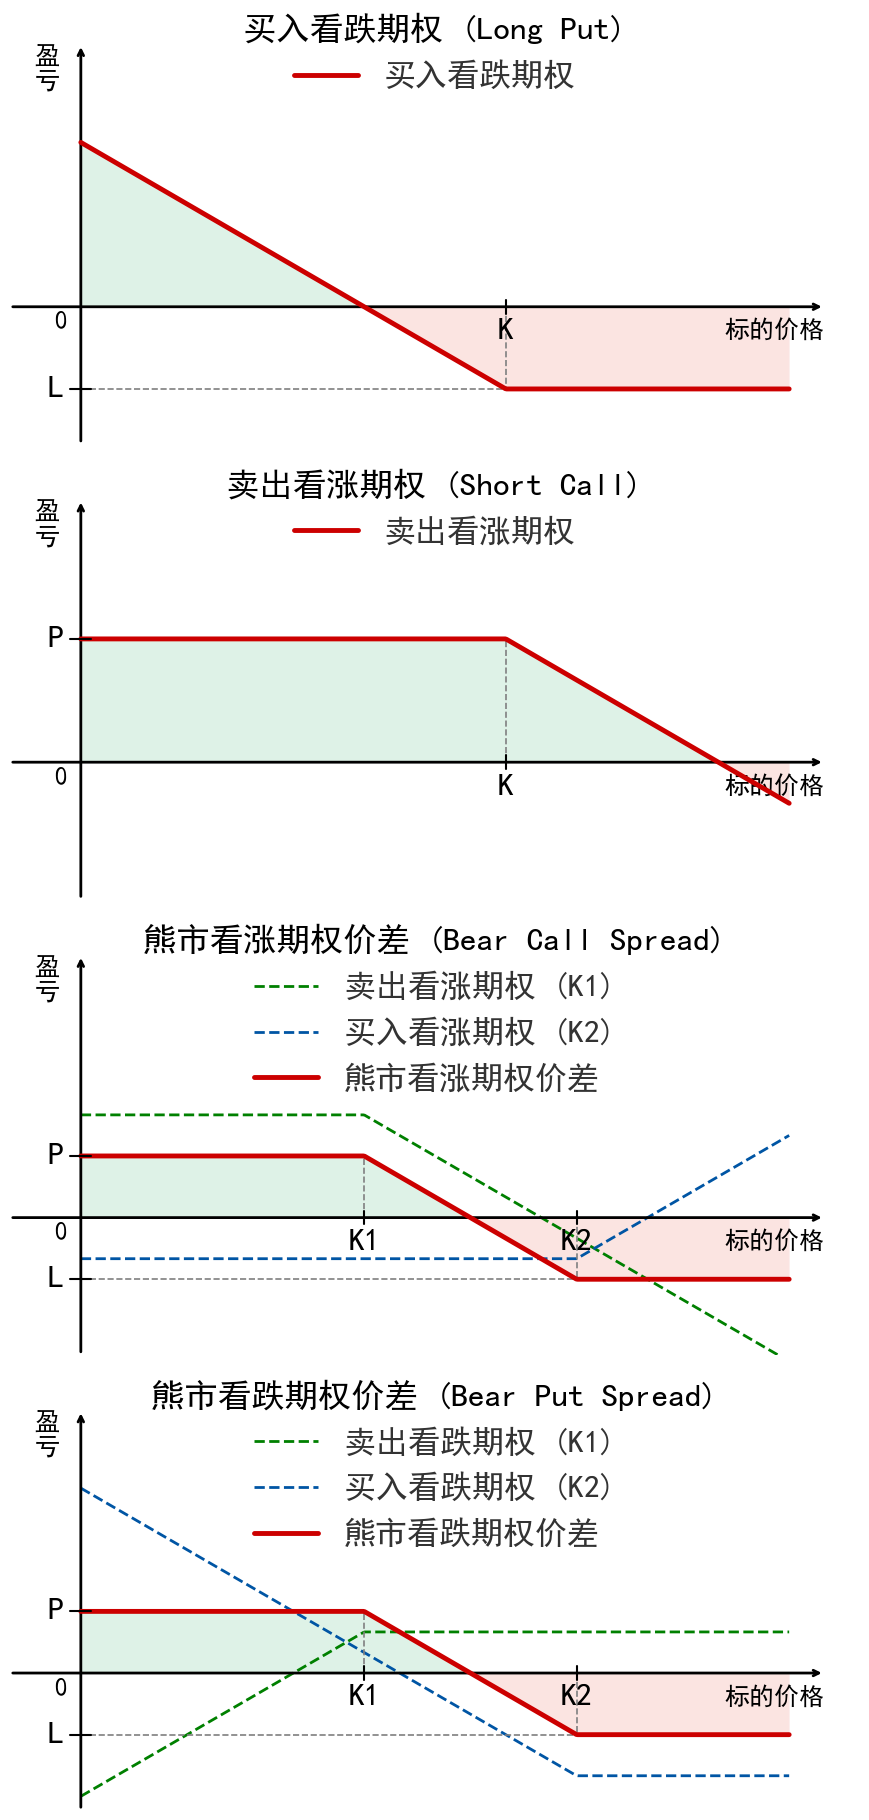

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ==========================================
# 0. 【全局控制面板】看空策略专属视觉与数学全控
# ==========================================
CONFIG = {
    # --- 1. 画布与排版间距 ---
    "FIG_SIZE": (10, 20),       # 画布尺寸：(宽度, 高度)
    "H_SPACE": 0.05,            # 图片之间的垂直间距：数值越大，图片离得越远
    "MARGINS": {                # 画布边缘留白 (0到1之间的比例)
        "left": 0.1, "right": 0.95, "top": 0.95, "bottom": 0.05
    },
    "TRANSPARENT_BG": True,     # 导出图片是否透明：True(透明)，False(使用底色)
    "BG_COLOR": "#FFFFFF",      # 画布底色：当 TRANSPARENT_BG 为 False 时生效

    # --- 2. 核心数学与图例位置控制 ---
    "SLOPE": 1.8,               # 曲线斜率倍数 (合约乘数)，修改此项会自动重算所有极值和参考线
    "LEGEND_LOC": "upper center", # 图例停靠基准
    "LEGEND_BBOX_X": 0.5,       # 图例 X 轴中心位置
    "LEGEND_BBOX_Y_1": 0.95,    # 单行图例时的 Y 轴偏移 (往下移)
    "LEGEND_BBOX_Y_2": 0.95,    # 双行图例时的 Y 轴偏移 (往下移)

    # --- 3. 文本内容设置 ---
    "TEXT_X_AXIS": "标的价格",
    "TEXT_Y_AXIS": "盈\n亏",

    # --- 4. 字体与字号设置 ---
    "FONT_FAMILY": "SimHei",
    "SIZE_TITLE": 24,
    "SIZE_AXIS": 18,
    "SIZE_ANNOT": 23,
    "SIZE_LEGEND": 23,

    # --- 5. 颜色库 ---
    "COLOR_MAIN": "#CC0000",    # 主收益线
    "COLOR_LEG1": "#0055A4",    # 分支期权1 (深蓝)
    "COLOR_LEG2": "#008000",    # 分支期权2 (翠绿)
    "COLOR_PROFIT": "#27AE60",  # 盈利区填充 (翠绿)
    "COLOR_LOSS": "#E74C3C",    # 亏损区填充 (亮红)
    "ALPHA_FILL": 0.15,         # 填充区透明度
    "COLOR_AXIS": "#000000",
    "COLOR_TEXT_TITLE": "black",
    "COLOR_TEXT_AXIS": "black",
    "COLOR_TEXT_LEGEND":"#333333",
    "COLOR_REF_LINE": "gray",

    # --- 6. 线条粗细 ---
    "LW_MAIN": 3.5,
    "LW_LEG": 2.0,
    "LW_AXIS": 2.0,
    "LW_REF": 1.2,
}

# ==========================================
# 1. 自动加载字体
# ==========================================
def get_safe_chinese_font():
    possible_paths = [
        "C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simsun.ttc"
    ]
    for path in possible_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            return font_prop
    fallback_fonts = [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei']
    for f in fallback_fonts:
        if f in [font.name for font in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [f]
            plt.rcParams['axes.unicode_minus'] = False
            return fm.FontProperties(family=f)
    return fm.FontProperties()

ch_font = get_safe_chinese_font()
font_kwargs = {'family': ch_font.get_name(), 'weight': 'bold'}

fig, axs = plt.subplots(4, 1, figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]: fig.patch.set_alpha(0)
else: fig.patch.set_facecolor(CONFIG["BG_COLOR"])

# ==========================================
# 2. 坐标轴与排版引擎
# ==========================================
def setup_options_axis(ax, title):
    ax.set_facecolor('none')
    for spine in ax.spines.values(): spine.set_visible(False)

    ax.annotate('', xy=(1.05, 0), xytext=(-0.1, 0), arrowprops=dict(arrowstyle="->", color=CONFIG["COLOR_AXIS"], lw=CONFIG["LW_AXIS"]))
    ax.annotate('', xy=(0, 1.15), xytext=(0, -0.6), arrowprops=dict(arrowstyle="->", color=CONFIG["COLOR_AXIS"], lw=CONFIG["LW_AXIS"]))

    ax.text(1.05, -0.05, CONFIG["TEXT_X_AXIS"], fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), ha='right', va='top', color=CONFIG["COLOR_TEXT_AXIS"])
    ax.text(-0.03, 1.15, CONFIG["TEXT_Y_AXIS"], fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), ha='right', va='top', color=CONFIG["COLOR_TEXT_AXIS"])
    ax.text(-0.02, -0.02, '0', ha='right', va='top', fontsize=CONFIG["SIZE_AXIS"], fontweight='bold', color=CONFIG["COLOR_TEXT_AXIS"])
    ax.text(0.5, 1.15, title, fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), ha='center', va='bottom', color=CONFIG["COLOR_TEXT_TITLE"])

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.6, 1.3)
    ax.set_xticks([])
    ax.set_yticks([])

# ==========================================
# 3. 辅助绘制函数
# ==========================================
def mark_xaxis(ax, x_val, text):
    tick = 0.03
    ax.plot([x_val, x_val], [-tick, tick], color=CONFIG["COLOR_AXIS"], lw=1.5, zorder=5)
    ax.text(x_val, -tick - 0.02, text, ha='center', va='top', fontsize=CONFIG["SIZE_ANNOT"], fontweight='bold', color=CONFIG["COLOR_TEXT_AXIS"])

def mark_yaxis(ax, y_val, text):
    tick = 0.015
    ax.plot([-tick, tick], [y_val, y_val], color=CONFIG["COLOR_AXIS"], lw=1.5, zorder=5)
    ax.text(-tick - 0.01, y_val, text, ha='right', va='center', fontsize=CONFIG["SIZE_ANNOT"], fontweight='bold', color=CONFIG["COLOR_TEXT_AXIS"])

def add_custom_legend(ax, is_multi_row=False, ncol=1):
    y_offset = CONFIG["LEGEND_BBOX_Y_2"] if is_multi_row else CONFIG["LEGEND_BBOX_Y_1"]
    ax.legend(prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc=CONFIG["LEGEND_LOC"],
              bbox_to_anchor=(CONFIG["LEGEND_BBOX_X"], y_offset), frameon=False, ncol=ncol, labelcolor=CONFIG["COLOR_TEXT_LEGEND"])

def fill_pnl(ax, x_vals, y_vals):
    ax.fill_between(x_vals, y_vals, 0, where=(y_vals > 0), facecolor=CONFIG["COLOR_PROFIT"], alpha=CONFIG["ALPHA_FILL"], interpolate=True, zorder=1)
    ax.fill_between(x_vals, y_vals, 0, where=(y_vals < 0), facecolor=CONFIG["COLOR_LOSS"], alpha=CONFIG["ALPHA_FILL"], interpolate=True, zorder=1)

# ==========================================
# 4. 看空策略图绘制核心
# ==========================================
x = np.linspace(0, 1.0, 500)
S = CONFIG["SLOPE"]

# --- 图1：买入看跌期权 (Long Put) ---
ax = axs[0]
setup_options_axis(ax, "买入看跌期权 (Long Put)")
k1, prm = 0.6, 0.2
y1 = S * (np.maximum(k1 - x, 0) - prm)

fill_pnl(ax, x, y1)
ax.plot(x, y1, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='买入看跌期权', zorder=3)

max_loss_1 = -S * prm
mark_xaxis(ax, k1, 'K')
mark_yaxis(ax, max_loss_1, 'L')

ax.plot([k1, k1], [0, max_loss_1], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([0, k1], [max_loss_1, max_loss_1], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=False)

# --- 图2：卖出看涨期权 (Short Call) ---
ax = axs[1]
setup_options_axis(ax, "卖出看涨期权 (Short Call)")
k2, prm = 0.6, 0.3
y2 = S * (prm - np.maximum(x - k2, 0))

fill_pnl(ax, x, y2)
ax.plot(x, y2, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='卖出看涨期权', zorder=3)

max_profit_2 = S * prm
mark_xaxis(ax, k2, 'K')
mark_yaxis(ax, max_profit_2, 'P')

ax.plot([k2, k2], [0, max_profit_2], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([0, k2], [max_profit_2, max_profit_2], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=False)

# --- 图3：熊市看涨期权价差 (Bear Call Spread) ---
# 逻辑：卖出低行权价Call (收高保费)，买入高行权价Call (付低保费防大涨)
ax = axs[2]
setup_options_axis(ax, "熊市看涨期权价差 (Bear Call Spread)")
k_low, k_high, c_low, c_high = 0.4, 0.7, 0.25, 0.1

leg1 = S * (c_low - np.maximum(x - k_low, 0))    # 卖出 Call (K1)
leg2 = S * (np.maximum(x - k_high, 0) - c_high)  # 买入 Call (K2)
combo = leg1 + leg2

max_profit_3 = S * (c_low - c_high)
max_loss_3 = max_profit_3 - S * (k_high - k_low)

fill_pnl(ax, x, combo)
ax.plot(x, leg1, color=CONFIG["COLOR_LEG2"], lw=CONFIG["LW_LEG"], ls='--', label='卖出看涨期权 (K1)', zorder=2) # 卖出腿通常用翠绿
ax.plot(x, leg2, color=CONFIG["COLOR_LEG1"], lw=CONFIG["LW_LEG"], ls='--', label='买入看涨期权 (K2)', zorder=2) # 买入腿通常用深蓝
ax.plot(x, combo, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='熊市看涨期权价差', zorder=4)

mark_xaxis(ax, k_low, 'K1')
mark_xaxis(ax, k_high, 'K2')
mark_yaxis(ax, max_profit_3, 'P')
mark_yaxis(ax, max_loss_3, 'L')

ax.plot([k_low, k_low], [0, max_profit_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([k_high, k_high], [0, max_loss_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([0, k_low], [max_profit_3, max_profit_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([0, k_high], [max_loss_3, max_loss_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=True, ncol=1)

# --- 图4：熊市看跌期权价差 (Bear Put Spread) ---
# 逻辑：买入高行权价Put (付高保费做空)，卖出低行权价Put (收低保费回血并锁定最大利润)
ax = axs[3]
setup_options_axis(ax, "熊市看跌期权价差 (Bear Put Spread)")
k_low, k_high, p_low, p_high = 0.4, 0.7, 0.1, 0.25

leg1 = S * (p_low - np.maximum(k_low - x, 0))    # 卖出 Put (K1)
leg2 = S * (np.maximum(k_high - x, 0) - p_high)  # 买入 Put (K2)
combo = leg1 + leg2

max_loss_4 = S * (p_low - p_high)
max_profit_4 = S * (k_high - k_low) + max_loss_4

fill_pnl(ax, x, combo)
ax.plot(x, leg1, color=CONFIG["COLOR_LEG2"], lw=CONFIG["LW_LEG"], ls='--', label='卖出看跌期权 (K1)', zorder=2)
ax.plot(x, leg2, color=CONFIG["COLOR_LEG1"], lw=CONFIG["LW_LEG"], ls='--', label='买入看跌期权 (K2)', zorder=2)
ax.plot(x, combo, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='熊市看跌期权价差', zorder=4)

mark_xaxis(ax, k_low, 'K1')
mark_xaxis(ax, k_high, 'K2')
mark_yaxis(ax, max_profit_4, 'P')
mark_yaxis(ax, max_loss_4, 'L')

ax.plot([k_low, k_low], [0, max_profit_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([k_high, k_high], [0, max_loss_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([0, k_low], [max_profit_4, max_profit_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([0, k_high], [max_loss_4, max_loss_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=True, ncol=1)

# ==========================================
# 5. 根据 CONFIG 参数应用布局并导出
# ==========================================
fig.subplots_adjust(
    left=CONFIG["MARGINS"]["left"],
    right=CONFIG["MARGINS"]["right"],
    top=CONFIG["MARGINS"]["top"],
    bottom=CONFIG["MARGINS"]["bottom"],
    hspace=CONFIG["H_SPACE"]
)

export_path = os.path.join(os.getcwd(), "期权策略图解_看空_盈亏轴标版.png")
fig.savefig(export_path, dpi=300, transparent=CONFIG["TRANSPARENT_BG"],
            facecolor=fig.get_facecolor(), edgecolor='none')
print(f"✅ 图片已根据配置导出至: {export_path}")

plt.show()

✅ 图片已根据配置导出至: E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\期权策略图解_看空_09.png


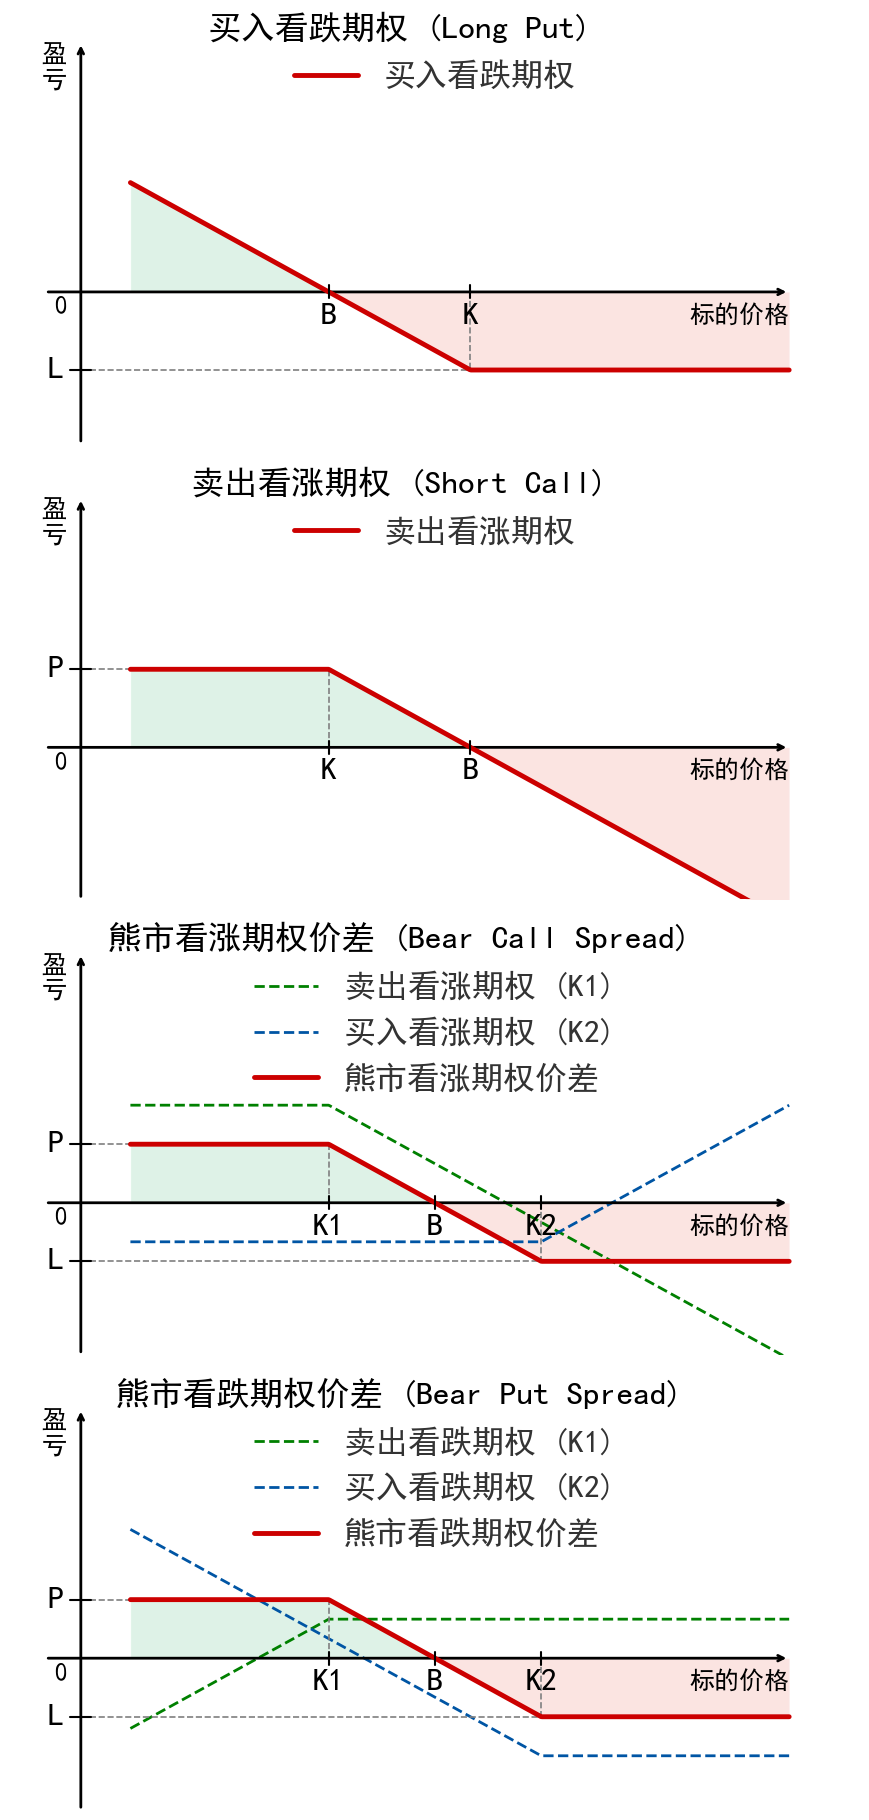

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ==========================================
# 0. 【全局控制面板】看空策略专属视觉与数学全控
# ==========================================
CONFIG = {
    # --- 1. 画布与排版间距 ---
    "FIG_SIZE": (10, 20),
    "H_SPACE": 0.05,
    "MARGINS": { "left": 0.1, "right": 0.95, "top": 0.95, "bottom": 0.05 },
    "TRANSPARENT_BG": True,
    "BG_COLOR": "#FFFFFF",

    # --- 2. 核心数学与图例位置控制 ---
    "SLOPE": 1.8,               # 曲线斜率倍数 (合约乘数)
    "X_ORIGIN": 0.05,           # 🌟 纵坐标(Y轴)物理位置
    "X_START": 0.12,            # 🌟 曲线开始绘制的位置 (留出空隙)
    "X_END": 1.05,              # 曲线结束绘制的位置 (延伸展现损失)

    "LEGEND_LOC": "upper center",
    "LEGEND_BBOX_X": 0.5,
    "LEGEND_BBOX_Y_1": 0.95,
    "LEGEND_BBOX_Y_2": 0.95,

    # --- 3. 文本内容设置 ---
    "TEXT_X_AXIS": "标的价格",
    "TEXT_Y_AXIS": "盈\n亏",

    # --- 4. 字体与字号设置 ---
    "FONT_FAMILY": "SimHei",
    "SIZE_TITLE": 24,
    "SIZE_AXIS": 18,
    "SIZE_ANNOT": 23,
    "SIZE_LEGEND": 23,

    # --- 5. 颜色库 ---
    "COLOR_MAIN": "#CC0000",    # 主收益线
    "COLOR_LEG1": "#0055A4",    # 分支期权1 (深蓝)
    "COLOR_LEG2": "#008000",    # 分支期权2 (翠绿)
    "COLOR_PROFIT": "#27AE60",  # 盈利区填充 (翠绿)
    "COLOR_LOSS": "#E74C3C",    # 亏损区填充 (亮红)
    "ALPHA_FILL": 0.15,
    "COLOR_AXIS": "#000000",
    "COLOR_TEXT_TITLE": "black",
    "COLOR_TEXT_AXIS": "black",
    "COLOR_TEXT_LEGEND":"#333333",
    "COLOR_REF_LINE": "gray",

    # --- 6. 线条粗细 ---
    "LW_MAIN": 3.5,
    "LW_LEG": 2.0,
    "LW_AXIS": 2.0,
    "LW_REF": 1.2,
}

# ==========================================
# 1. 自动加载字体
# ==========================================
def get_safe_chinese_font():
    possible_paths = [
        "C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simsun.ttc"
    ]
    for path in possible_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            return font_prop
    fallback_fonts = [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei']
    for f in fallback_fonts:
        if f in [font.name for font in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [f]
            plt.rcParams['axes.unicode_minus'] = False
            return fm.FontProperties(family=f)
    return fm.FontProperties()

ch_font = get_safe_chinese_font()
font_kwargs = {'family': ch_font.get_name(), 'weight': 'bold'}

fig, axs = plt.subplots(4, 1, figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]: fig.patch.set_alpha(0)
else: fig.patch.set_facecolor(CONFIG["BG_COLOR"])

# ==========================================
# 2. 坐标轴与排版引擎 (🌟纵坐标剥离空隙)
# ==========================================
def setup_options_axis(ax, title):
    ax.set_facecolor('none')
    for spine in ax.spines.values(): spine.set_visible(False)

    X_ORIGIN = CONFIG["X_ORIGIN"]

    # 绘制坐标轴主干，将Y轴固定在 X_ORIGIN
    ax.annotate('', xy=(1.05, 0), xytext=(X_ORIGIN-0.05, 0), arrowprops=dict(arrowstyle="->", color=CONFIG["COLOR_AXIS"], lw=CONFIG["LW_AXIS"]))
    ax.annotate('', xy=(X_ORIGIN, 1.15), xytext=(X_ORIGIN, -0.7), arrowprops=dict(arrowstyle="->", color=CONFIG["COLOR_AXIS"], lw=CONFIG["LW_AXIS"]))

    # 轴标题与原点
    ax.text(1.05, -0.05, CONFIG["TEXT_X_AXIS"], fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), ha='right', va='top', color=CONFIG["COLOR_TEXT_AXIS"])
    ax.text(X_ORIGIN-0.02, 1.15, CONFIG["TEXT_Y_AXIS"], fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), ha='right', va='top', color=CONFIG["COLOR_TEXT_AXIS"])
    ax.text(X_ORIGIN-0.02, -0.02, '0', ha='right', va='top', fontsize=CONFIG["SIZE_AXIS"], fontweight='bold', color=CONFIG["COLOR_TEXT_AXIS"])
    ax.text(0.5, 1.15, title, fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), ha='center', va='bottom', color=CONFIG["COLOR_TEXT_TITLE"])

    ax.set_xlim(-0.05, 1.15)
    ax.set_ylim(-0.7, 1.3)
    ax.set_xticks([])
    ax.set_yticks([])

# ==========================================
# 3. 辅助绘制函数
# ==========================================
def mark_xaxis(ax, x_val, text):
    tick = 0.03
    ax.plot([x_val, x_val], [-tick, tick], color=CONFIG["COLOR_AXIS"], lw=1.5, zorder=5)
    ax.text(x_val, -tick - 0.02, text, ha='center', va='top', fontsize=CONFIG["SIZE_ANNOT"], fontweight='bold', color=CONFIG["COLOR_TEXT_AXIS"])

def mark_yaxis(ax, y_val, text):
    tick = 0.015
    X_ORIGIN = CONFIG["X_ORIGIN"]
    # 将纵向刻度打在偏移后的 Y 轴上
    ax.plot([X_ORIGIN-tick, X_ORIGIN+tick], [y_val, y_val], color=CONFIG["COLOR_AXIS"], lw=1.5, zorder=5)
    ax.text(X_ORIGIN-tick - 0.01, y_val, text, ha='right', va='center', fontsize=CONFIG["SIZE_ANNOT"], fontweight='bold', color=CONFIG["COLOR_TEXT_AXIS"])

def add_custom_legend(ax, is_multi_row=False, ncol=1):
    y_offset = CONFIG["LEGEND_BBOX_Y_2"] if is_multi_row else CONFIG["LEGEND_BBOX_Y_1"]
    ax.legend(prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc=CONFIG["LEGEND_LOC"],
              bbox_to_anchor=(CONFIG["LEGEND_BBOX_X"], y_offset), frameon=False, ncol=ncol, labelcolor=CONFIG["COLOR_TEXT_LEGEND"])

def fill_pnl(ax, x_vals, y_vals):
    ax.fill_between(x_vals, y_vals, 0, where=(y_vals > 0), facecolor=CONFIG["COLOR_PROFIT"], alpha=CONFIG["ALPHA_FILL"], interpolate=True, zorder=1)
    ax.fill_between(x_vals, y_vals, 0, where=(y_vals < 0), facecolor=CONFIG["COLOR_LOSS"], alpha=CONFIG["ALPHA_FILL"], interpolate=True, zorder=1)

# ==========================================
# 4. 看空策略图绘制核心
# ==========================================
# 🌟 曲线强制从 X_START(0.12) 开始画，不碰 X_ORIGIN(0.05) 的纵轴
x = np.linspace(CONFIG["X_START"], CONFIG["X_END"], 500)
S = CONFIG["SLOPE"]
X_ORIGIN = CONFIG["X_ORIGIN"]

# --- 图1：买入看跌期权 (Long Put) ---
ax = axs[0]
setup_options_axis(ax, "买入看跌期权 (Long Put)")
k1, prm = 0.6, 0.2
b1 = k1 - prm  # 🌟 计算平衡点 B

y1 = S * (np.maximum(k1 - x, 0) - prm)

fill_pnl(ax, x, y1)
ax.plot(x, y1, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='买入看跌期权', zorder=3)

max_loss_1 = -S * prm
mark_xaxis(ax, k1, 'K')
mark_xaxis(ax, b1, 'B')  # 标注平衡点
mark_yaxis(ax, max_loss_1, 'L')

ax.plot([k1, k1], [0, max_loss_1], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
# 参考线退回到 X_ORIGIN
ax.plot([X_ORIGIN, k1], [max_loss_1, max_loss_1], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=False)

# --- 图2：卖出看涨期权 (Short Call) ---
ax = axs[1]
setup_options_axis(ax, "卖出看涨期权 (Short Call)")
k2, prm = 0.4, 0.2
b2 = k2 + prm  # 🌟 计算平衡点 B

y2 = S * (prm - np.maximum(x - k2, 0))

fill_pnl(ax, x, y2)
ax.plot(x, y2, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='卖出看涨期权', zorder=3)

max_profit_2 = S * prm
mark_xaxis(ax, k2, 'K')
mark_xaxis(ax, b2, 'B')  # 标注平衡点
mark_yaxis(ax, max_profit_2, 'P')

ax.plot([k2, k2], [0, max_profit_2], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([X_ORIGIN, k2], [max_profit_2, max_profit_2], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=False)

# --- 图3：熊市看涨期权价差 (Bear Call Spread) ---
ax = axs[2]
setup_options_axis(ax, "熊市看涨期权价差 (Bear Call Spread)")
k_low, k_high, c_low, c_high = 0.4, 0.7, 0.25, 0.1
b3 = k_low + c_low - c_high  # 🌟 计算平衡点 B

leg1 = S * (c_low - np.maximum(x - k_low, 0))
leg2 = S * (np.maximum(x - k_high, 0) - c_high)
combo = leg1 + leg2

max_profit_3 = S * (c_low - c_high)
max_loss_3 = max_profit_3 - S * (k_high - k_low)

fill_pnl(ax, x, combo)
ax.plot(x, leg1, color=CONFIG["COLOR_LEG2"], lw=CONFIG["LW_LEG"], ls='--', label='卖出看涨期权 (K1)', zorder=2)
ax.plot(x, leg2, color=CONFIG["COLOR_LEG1"], lw=CONFIG["LW_LEG"], ls='--', label='买入看涨期权 (K2)', zorder=2)
ax.plot(x, combo, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='熊市看涨期权价差', zorder=4)

mark_xaxis(ax, k_low, 'K1')
mark_xaxis(ax, k_high, 'K2')
mark_xaxis(ax, b3, 'B')  # 标注平衡点
mark_yaxis(ax, max_profit_3, 'P')
mark_yaxis(ax, max_loss_3, 'L')

ax.plot([k_low, k_low], [0, max_profit_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([k_high, k_high], [0, max_loss_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([X_ORIGIN, k_low], [max_profit_3, max_profit_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([X_ORIGIN, k_high], [max_loss_3, max_loss_3], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=True, ncol=1)

# --- 图4：熊市看跌期权价差 (Bear Put Spread) ---
ax = axs[3]
setup_options_axis(ax, "熊市看跌期权价差 (Bear Put Spread)")
k_low, k_high, p_low, p_high = 0.4, 0.7, 0.1, 0.25
b4 = k_high + p_low - p_high  # 🌟 计算平衡点 B

leg1 = S * (p_low - np.maximum(k_low - x, 0))
leg2 = S * (np.maximum(k_high - x, 0) - p_high)
combo = leg1 + leg2

max_loss_4 = S * (p_low - p_high)
max_profit_4 = S * (k_high - k_low) + max_loss_4

fill_pnl(ax, x, combo)
ax.plot(x, leg1, color=CONFIG["COLOR_LEG2"], lw=CONFIG["LW_LEG"], ls='--', label='卖出看跌期权 (K1)', zorder=2)
ax.plot(x, leg2, color=CONFIG["COLOR_LEG1"], lw=CONFIG["LW_LEG"], ls='--', label='买入看跌期权 (K2)', zorder=2)
ax.plot(x, combo, color=CONFIG["COLOR_MAIN"], lw=CONFIG["LW_MAIN"], label='熊市看跌期权价差', zorder=4)

mark_xaxis(ax, k_low, 'K1')
mark_xaxis(ax, k_high, 'K2')
mark_xaxis(ax, b4, 'B')  # 标注平衡点
mark_yaxis(ax, max_profit_4, 'P')
mark_yaxis(ax, max_loss_4, 'L')

ax.plot([k_low, k_low], [0, max_profit_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([k_high, k_high], [0, max_loss_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([X_ORIGIN, k_low], [max_profit_4, max_profit_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
ax.plot([X_ORIGIN, k_high], [max_loss_4, max_loss_4], color=CONFIG["COLOR_REF_LINE"], ls='--', lw=CONFIG["LW_REF"])
add_custom_legend(ax, is_multi_row=True, ncol=1)

# ==========================================
# 5. 导出应用
# ==========================================
fig.subplots_adjust(
    left=CONFIG["MARGINS"]["left"],
    right=CONFIG["MARGINS"]["right"],
    top=CONFIG["MARGINS"]["top"],
    bottom=CONFIG["MARGINS"]["bottom"],
    hspace=CONFIG["H_SPACE"]
)

export_path = os.path.join(os.getcwd(), "期权策略图解_看空_09.png")
fig.savefig(export_path, dpi=300, transparent=CONFIG["TRANSPARENT_BG"],
            facecolor=fig.get_facecolor(), edgecolor='none')
print(f"✅ 图片已根据配置导出至: {export_path}")

plt.show()

正在获取 SPY 最新市价...
图像成功导出为: SPY_期权卖方综合分析.png


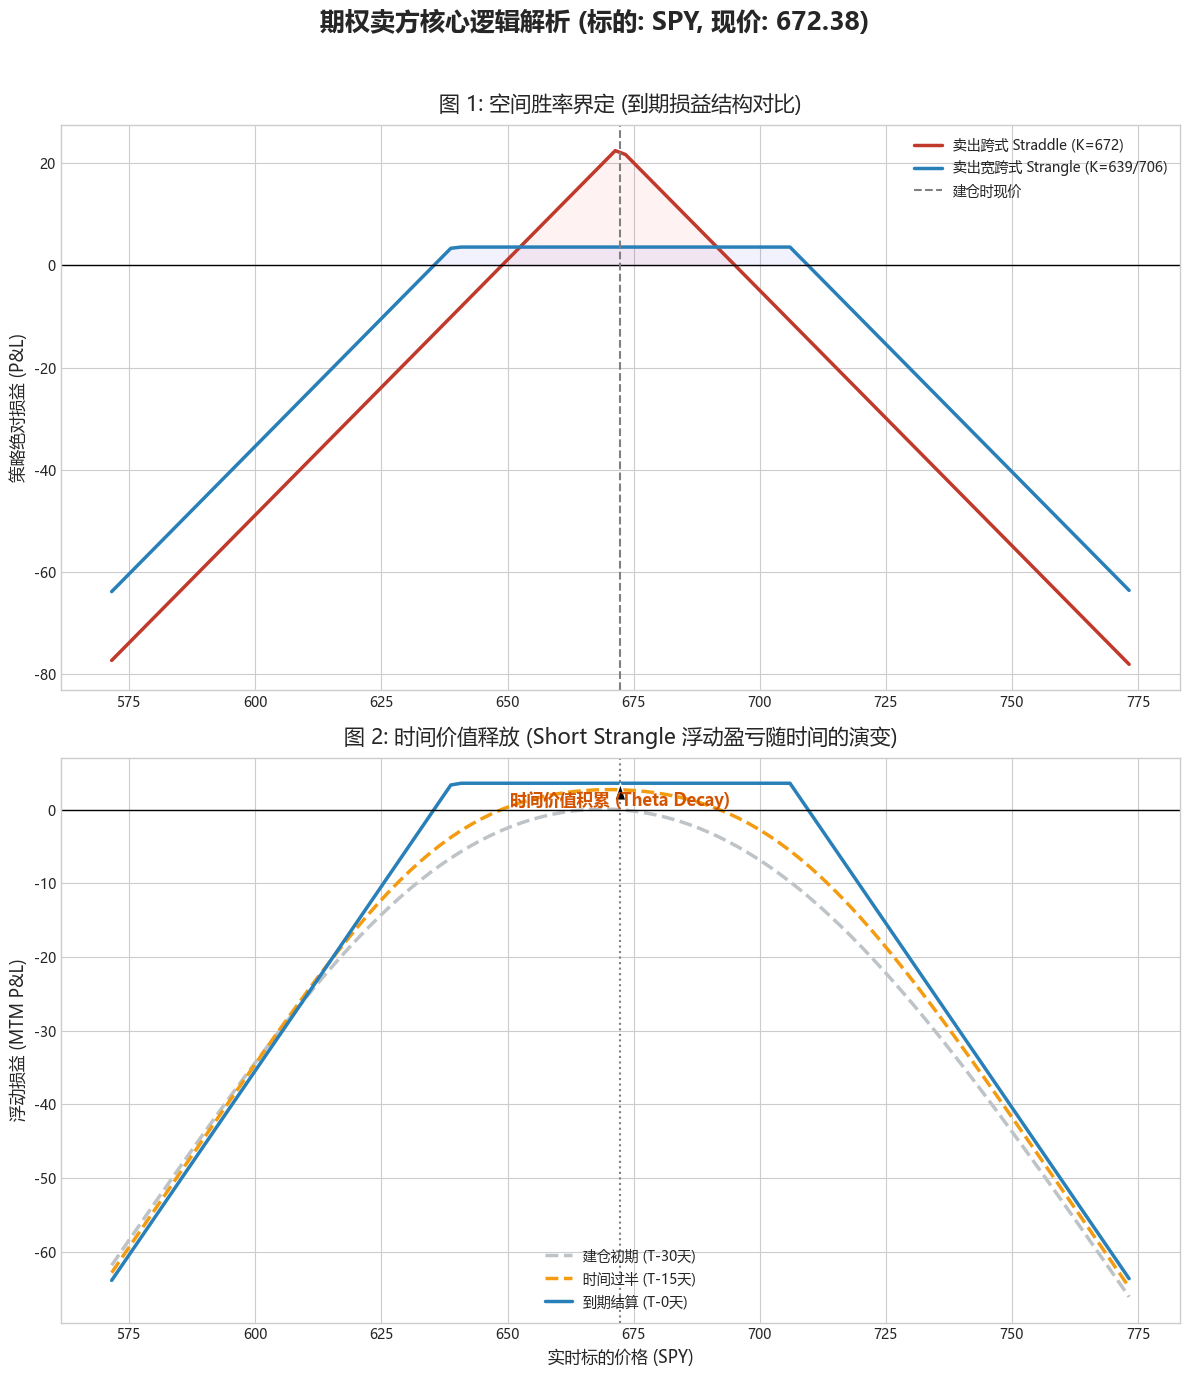

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si
import time

# --- 配置区 ---
TICKER_NAME = "SPY"
SAVE_FILENAME = f"{TICKER_NAME}_期权卖方综合分析.png"
# --------------

# 1. 环境与字体配置
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

# 2. 获取现价与设定模型参数
print(f"正在获取 {TICKER_NAME} 最新市价...")
spot_price = yf.Ticker(TICKER_NAME).history(period="1d")['Close'].iloc[-1]
volatility = 0.15  # 假设隐含波动率 (15%)
r = 0.04           # 无风险利率 (4%)

# 设定行权价与标的价格区间
k_atm = round(spot_price)
k_put_otm = round(spot_price * 0.95)
k_call_otm = round(spot_price * 1.05)
s_range = np.linspace(spot_price * 0.85, spot_price * 1.15, 100)

# 3. B-S 期权定价公式
def bs_price(S, K, T, r, sigma, option_type='call'):
    # 如果已经到期，直接返回内在价值
    if T <= 0:
        return np.maximum(S - K, 0) if option_type == 'call' else np.maximum(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

# 计算初始期权费 (假设距离到期 30 天)
T_initial = 30 / 365
p_strangle = (bs_price(spot_price, k_put_otm, T_initial, r, volatility, 'put') +
              bs_price(spot_price, k_call_otm, T_initial, r, volatility, 'call'))
p_straddle = (bs_price(spot_price, k_atm, T_initial, r, volatility, 'put') +
              bs_price(spot_price, k_atm, T_initial, r, volatility, 'call'))

# ==========================================
# 4. 创建上下排列的画布
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), sharex=False)
fig.suptitle(f'期权卖方核心逻辑解析 (标的: {TICKER_NAME}, 现价: {spot_price:.2f})',
             fontsize=18, fontweight='bold', y=0.98)

# --- 上图 (ax1)：空间维度 - 到期损益结构对比 ---
payoff_std = p_straddle - np.maximum(s_range - k_atm, 0) - np.maximum(k_atm - s_range, 0)
payoff_stg = p_strangle - np.maximum(s_range - k_call_otm, 0) - np.maximum(k_put_otm - s_range, 0)

ax1.plot(s_range, payoff_std, label=f'卖出跨式 Straddle (K={k_atm})', color='#C0392B', lw=2.5)
ax1.plot(s_range, payoff_stg, label=f'卖出宽跨式 Strangle (K={k_put_otm}/{k_call_otm})', color='#2980B9', lw=2.5)

ax1.axhline(0, color='black', lw=1)
ax1.axvline(spot_price, color='gray', ls='--', label='建仓时现价')
ax1.fill_between(s_range, 0, payoff_std, where=(payoff_std > 0), color='red', alpha=0.05)
ax1.fill_between(s_range, 0, payoff_stg, where=(payoff_stg > 0), color='blue', alpha=0.05)

ax1.set_title('图 1: 空间胜率界定 (到期损益结构对比)', fontsize=15, pad=10)
ax1.set_ylabel('策略绝对损益 (P&L)', fontsize=12)
ax1.legend(loc='upper right')

# --- 下图 (ax2)：时间维度 - Strangle 策略的 Theta 收益积累 ---
time_steps = [30, 15, 0] # 距离到期天数
colors = ['#BDC3C7', '#F39C12', '#2980B9']
labels = ['建仓初期 (T-30天)', '时间过半 (T-15天)', '到期结算 (T-0天)']

for t_days, color, label in zip(time_steps, colors, labels):
    T_current = t_days / 365
    current_cost = [bs_price(S, k_put_otm, T_current, r, volatility, 'put') +
                    bs_price(S, k_call_otm, T_current, r, volatility, 'call') for S in s_range]
    pnl = p_strangle - np.array(current_cost)

    line_style = '-' if t_days == 0 else '--'
    ax2.plot(s_range, pnl, label=label, color=color, lw=2.5, ls=line_style)

ax2.axhline(0, color='black', lw=1)
ax2.axvline(spot_price, color='gray', ls=':')

# 标注 Theta 衰减箭头
ax2.annotate('时间价值积累 (Theta Decay)', xy=(spot_price, p_strangle),
             xytext=(spot_price, 0),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', va='bottom', fontsize=12, color='#D35400', fontweight='bold')

ax2.set_title('图 2: 时间价值释放 (Short Strangle 浮动盈亏随时间的演变)', fontsize=15, pad=10)
ax2.set_xlabel(f'实时标的价格 ({TICKER_NAME})', fontsize=12)
ax2.set_ylabel('浮动损益 (MTM P&L)', fontsize=12)
ax2.legend(loc='lower center')

# ==========================================
# 5. 调整布局并导出
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.96]) # 给总标题留出空间
plt.savefig(SAVE_FILENAME, transparent=True, dpi=300)
print(f"图像成功导出为: {SAVE_FILENAME}")
plt.show()

🔄 正在获取 SPY 最新市价...
✅ 期权卖方分析图表已成功导出至:
📁 E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\SPY_期权卖方综合分析_全控版.png


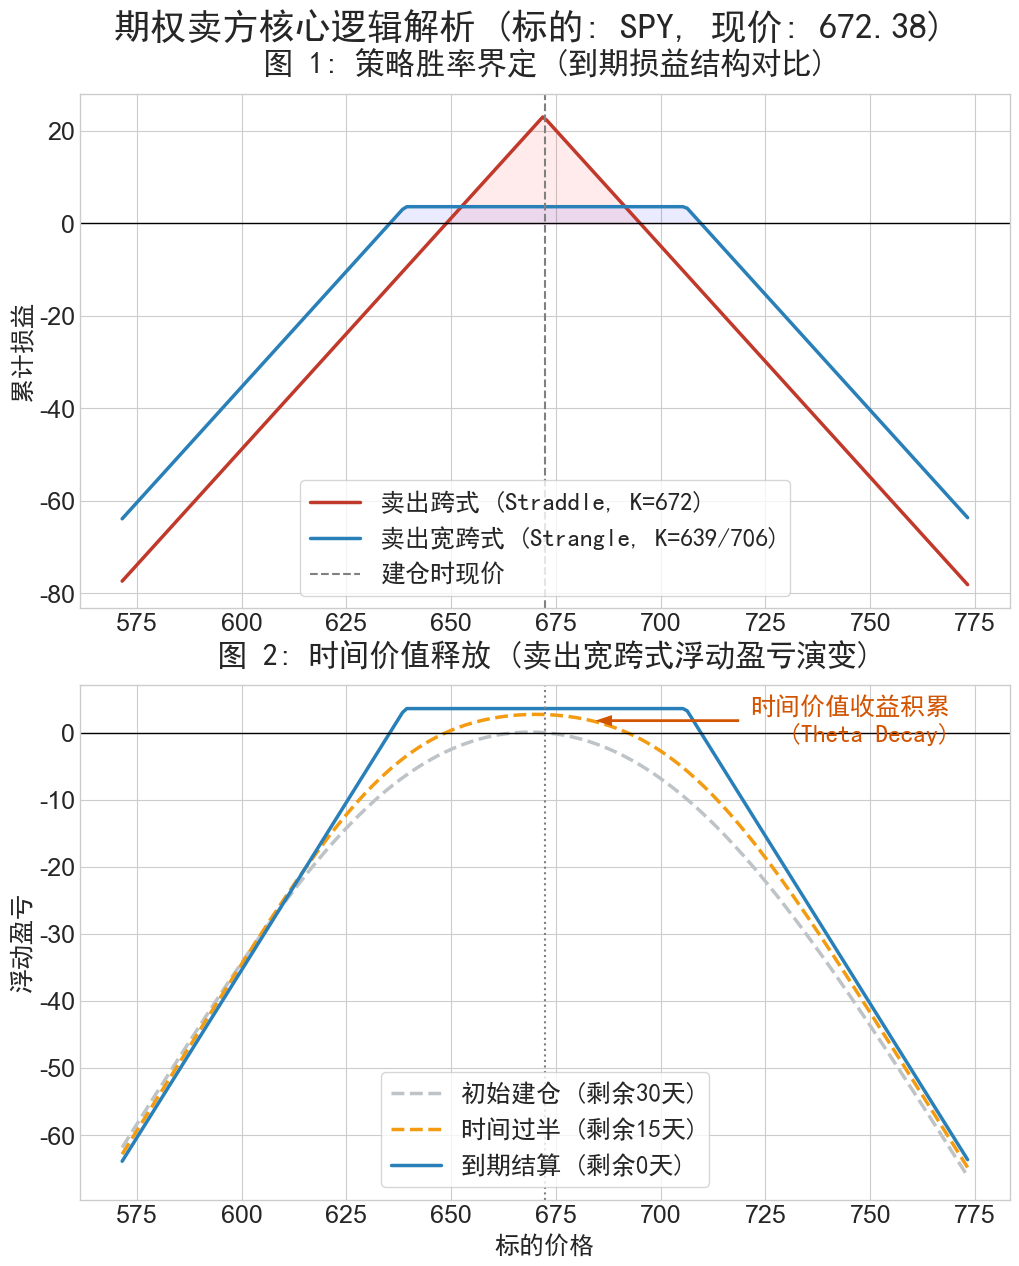

In [5]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import scipy.stats as si
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 0. 【期权卖方综合分析】全局控制面板
# ==========================================
CONFIG = {
    # --- 1. 核心金融参数与标的设置 ---
    "TICKER": "SPY",             # 分析标的代码
    "FALLBACK_PRICE": 450.0,     # 如果断网无法获取市价，使用的默认现价
    "VOLATILITY": 0.15,          # 隐含波动率 (IV，默认 15%)
    "RISK_FREE_RATE": 0.04,      # 无风险利率 (Risk-free Rate，默认 4%)
    "DAYS_TO_EXPIRY": 30,        # 初始建仓时的到期天数 (DTE)
    "STRIKE_OTM_PCT": 0.05,      # 宽跨式虚值程度 (0.05 代表上下偏离 5% 设为行权价)

    # --- 2. 画布尺寸与排版间距 ---
    "FIG_SIZE": (12, 14),        # 上下双图的总尺寸 (宽, 高)
    "H_SPACE": 0.15,             # 上下两张图表之间的垂直间距
    "DPI": 600,                  # 导出图片清晰度
    "TRANSPARENT_BG": True,      # 是否导出透明背景
    "BG_COLOR": "#FFFFFF",       # 非透明状态下的底色

    # --- 3. 字体与字号设定 ---
    "FONT_FAMILY": "SimHei",     # 全局中文字体
    "SIZE_MAIN_TITLE": 26,       # 整个大画布的主标题字号
    "SIZE_SUB_TITLE": 22,        # 两个子图的标题字号
    "SIZE_AXIS_LABEL": 18,       # X/Y 轴名称字号
    "SIZE_TICK": 18,             # 坐标轴刻度数字字号
    "SIZE_ANNOT": 18,            # 图中文字标注 (如 Theta 箭头) 字号
    "SIZE_LEGEND": 18,           # 图例字号

    # --- 4. 核心配色库 (高对比度投研风) ---
    "C_STRADDLE": "#C0392B",     # 卖出跨式 (Straddle) 的主线颜色 - 红色
    "C_STRANGLE": "#2980B9",     # 卖出宽跨式 (Strangle) 的主线颜色 - 蓝色
    "C_TIME_START": "#BDC3C7",   # 初始建仓时的浮动盈亏线 - 浅灰
    "C_TIME_MID": "#F39C12",     # 时间过半时的浮动盈亏线 - 橙色
    "C_TIME_END": "#2980B9",     # 到期结算时的最终损益线 - 蓝色

    "C_FILL_STRADDLE": "red",    # 跨式胜率(盈利)区间填充色
    "C_FILL_STRANGLE": "blue",   # 宽跨式胜率(盈利)区间填充色
    "ALPHA_FILL": 0.08,          # 盈利区间填充颜色的透明度
    "C_ARROW": "#D35400",        # Theta 衰减指示箭头的颜色
    "C_AXIS_ZERO": "black",      # 0轴基准线颜色
    "C_SPOT_LINE": "gray",       # 现价垂直参考线颜色

    # --- 5. 线条粗细 ---
    "LW_MAIN": 2.5,              # 收益主线的粗细
    "LW_ZERO": 1.0,              # 0轴基准线粗细
    "LW_SPOT": 1.5,              # 现价垂直参考线粗细
}

# ==========================================
# 1. 自动加载安全字体与环境初始化
# ==========================================
def get_safe_chinese_font():
    possible_paths = ["C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simsun.ttc"]
    for path in possible_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            return font_prop

    for f in [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei']:
        if f in [font.name for font in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [f]
            plt.rcParams['axes.unicode_minus'] = False
            return fm.FontProperties(family=f)
    return fm.FontProperties()

ch_font = get_safe_chinese_font()
font_kwargs = {'family': ch_font.get_name(), 'weight': 'bold'}
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 2. 获取现价与设定模型参数
# ==========================================
print(f"🔄 正在获取 {CONFIG['TICKER']} 最新市价...")
try:
    spot_price = yf.Ticker(CONFIG["TICKER"]).history(period="1d")['Close'].iloc[-1]
except:
    print("⚠️ 无法获取实时数据，切换为 Fallback 现价。")
    spot_price = CONFIG["FALLBACK_PRICE"]

# 提取核心参数
volatility = CONFIG["VOLATILITY"]
r = CONFIG["RISK_FREE_RATE"]
T_initial = CONFIG["DAYS_TO_EXPIRY"] / 365.0

# 计算平值(ATM)与虚值(OTM)行权价
k_atm = round(spot_price)
k_put_otm = round(spot_price * (1 - CONFIG["STRIKE_OTM_PCT"]))
k_call_otm = round(spot_price * (1 + CONFIG["STRIKE_OTM_PCT"]))

# 构建价格横轴区间 (上下浮动 15%)
s_range = np.linspace(spot_price * 0.85, spot_price * 1.15, 200)

# ==========================================
# 3. 矢量化 B-S 期权定价公式
# ==========================================
def bs_price(S, K, T, r, sigma, option_type='call'):
    """经优化的 Black-Scholes 模型计算函数 (支持 numpy 数组运算)"""
    if T <= 0:
        return np.maximum(S - K, 0) if option_type == 'call' else np.maximum(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

# 计算初始期权权利金收入
p_strangle = (bs_price(spot_price, k_put_otm, T_initial, r, volatility, 'put') +
              bs_price(spot_price, k_call_otm, T_initial, r, volatility, 'call'))

p_straddle = (bs_price(spot_price, k_atm, T_initial, r, volatility, 'put') +
              bs_price(spot_price, k_atm, T_initial, r, volatility, 'call'))

# ==========================================
# 4. 创建上下排列的画布
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=CONFIG["FIG_SIZE"], sharex=False)
if CONFIG["TRANSPARENT_BG"]: fig.patch.set_alpha(0)
else: fig.patch.set_facecolor(CONFIG["BG_COLOR"])

fig.suptitle(f'期权卖方核心逻辑解析 (标的: {CONFIG["TICKER"]}, 现价: {spot_price:.2f})',
             fontproperties=fm.FontProperties(size=CONFIG["SIZE_MAIN_TITLE"], **font_kwargs), y=0.96)

# ------------------------------------------
# 图 1 (ax1)：空间维度 - 到期损益结构对比
# ------------------------------------------
payoff_std = p_straddle - np.maximum(s_range - k_atm, 0) - np.maximum(k_atm - s_range, 0)
payoff_stg = p_strangle - np.maximum(s_range - k_call_otm, 0) - np.maximum(k_put_otm - s_range, 0)

ax1.plot(s_range, payoff_std, label=f'卖出跨式 (Straddle, K={k_atm})', color=CONFIG["C_STRADDLE"], lw=CONFIG["LW_MAIN"])
ax1.plot(s_range, payoff_stg, label=f'卖出宽跨式 (Strangle, K={k_put_otm}/{k_call_otm})', color=CONFIG["C_STRANGLE"], lw=CONFIG["LW_MAIN"])

ax1.axhline(0, color=CONFIG["C_AXIS_ZERO"], lw=CONFIG["LW_ZERO"])
ax1.axvline(spot_price, color=CONFIG["C_SPOT_LINE"], ls='--', lw=CONFIG["LW_SPOT"], label='建仓时现价')

# 盈利区间面积填充
ax1.fill_between(s_range, 0, payoff_std, where=(payoff_std > 0), color=CONFIG["C_FILL_STRADDLE"], alpha=CONFIG["ALPHA_FILL"])
ax1.fill_between(s_range, 0, payoff_stg, where=(payoff_stg > 0), color=CONFIG["C_FILL_STRANGLE"], alpha=CONFIG["ALPHA_FILL"])

ax1.set_title('图 1: 策略胜率界定 (到期损益结构对比)', fontproperties=fm.FontProperties(size=CONFIG["SIZE_SUB_TITLE"], **font_kwargs), pad=15)
ax1.set_ylabel('累计损益', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS_LABEL"], **font_kwargs))
ax1.tick_params(labelsize=CONFIG["SIZE_TICK"])
ax1.legend(prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='lower center', frameon=True)

# ------------------------------------------
# 图 2 (ax2)：时间维度 - Strangle 策略时间价值演变
# ------------------------------------------
time_steps = [CONFIG["DAYS_TO_EXPIRY"], CONFIG["DAYS_TO_EXPIRY"] // 2, 0]
colors = [CONFIG["C_TIME_START"], CONFIG["C_TIME_MID"], CONFIG["C_TIME_END"]]
labels = [f'初始建仓 (剩余{time_steps[0]}天)', f'时间过半 (剩余{time_steps[1]}天)', '到期结算 (剩余0天)']

for t_days, color, label in zip(time_steps, colors, labels):
    T_current = t_days / 365.0
    # 矢量化计算加速
    current_cost = bs_price(s_range, k_put_otm, T_current, r, volatility, 'put') + \
                   bs_price(s_range, k_call_otm, T_current, r, volatility, 'call')
    pnl = p_strangle - current_cost
    line_style = '-' if t_days == 0 else '--'
    ax2.plot(s_range, pnl, label=label, color=color, lw=CONFIG["LW_MAIN"], ls=line_style)

ax2.axhline(0, color=CONFIG["C_AXIS_ZERO"], lw=CONFIG["LW_ZERO"])
ax2.axvline(spot_price, color=CONFIG["C_SPOT_LINE"], ls=':', lw=CONFIG["LW_SPOT"])

# 标注 Theta 衰减箭头
#找到最右侧的横坐标位置 (取 s_range 的接近末端)
text_x_right = s_range[-5]
# 设定箭头处于上下曲线中间的高度 (最大收益的一半处最美观)
mid_y = p_strangle * 0.5

# 标注 Theta 衰减箭头 (文字在右，箭头向左水平指向中心缝隙)
ax2.annotate('时间价值收益积累\n(Theta Decay)',
             xy=(spot_price + (spot_price * 0.015), mid_y), # 箭头尖端指向中间缝隙的右边缘
             xytext=(text_x_right, mid_y),                  # 文字停靠在最右侧
             arrowprops=dict(facecolor=CONFIG["C_ARROW"], shrink=0.05, width=2.0, headwidth=8, edgecolor='none'),
             ha='right', va='center',
             fontproperties=fm.FontProperties(size=CONFIG["SIZE_ANNOT"], **font_kwargs), color=CONFIG["C_ARROW"])

ax2.set_title('图 2: 时间价值释放 (卖出宽跨式浮动盈亏演变)', fontproperties=fm.FontProperties(size=CONFIG["SIZE_SUB_TITLE"], **font_kwargs), pad=15)
ax2.set_xlabel('标的价格', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS_LABEL"], **font_kwargs))
ax2.set_ylabel('浮动盈亏', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS_LABEL"], **font_kwargs))
ax2.tick_params(labelsize=CONFIG["SIZE_TICK"])
ax2.legend(prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='lower center', frameon=True)

# ==========================================
# 5. 调整布局并导出
# ==========================================
plt.subplots_adjust(hspace=CONFIG["H_SPACE"], top=0.90)

export_path = os.path.join(os.getcwd(), f"{CONFIG['TICKER']}_期权卖方综合分析_全控版.png")
plt.savefig(export_path, transparent=CONFIG["TRANSPARENT_BG"], dpi=CONFIG["DPI"], bbox_inches='tight')
print(f"✅ 期权卖方分析图表已成功导出至:\n📁 {export_path}")

plt.show()

🚀 正在尝试从 yfinance 抓取真实数据: State Street SPDR S&P 500 ETF Trust (SPY)...
✅ 真实数据抓取并清洗完毕。

✅ 图片已成功应用 CONFIG 配置并导出: 
1. 📁 E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\State Street SPDR SP 500 ETF Trust_曲面全控版_0308_0059.png
2. 📁 E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\State Street SPDR SP 500 ETF Trust_热力图全控版_0308_0059.png


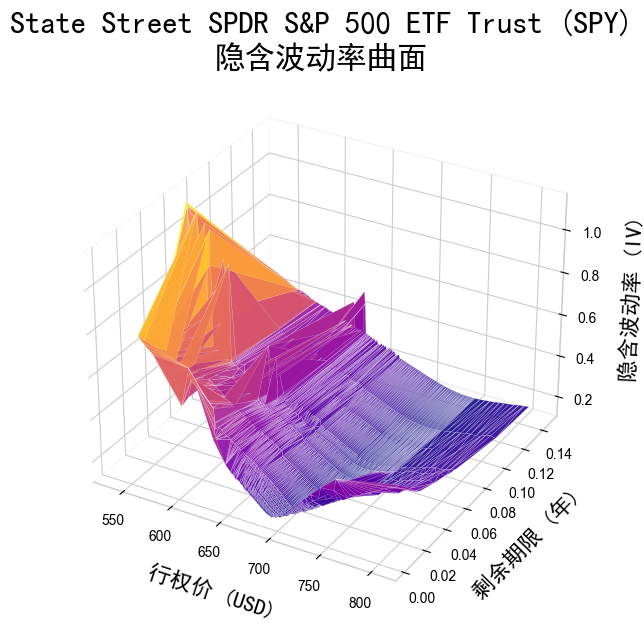

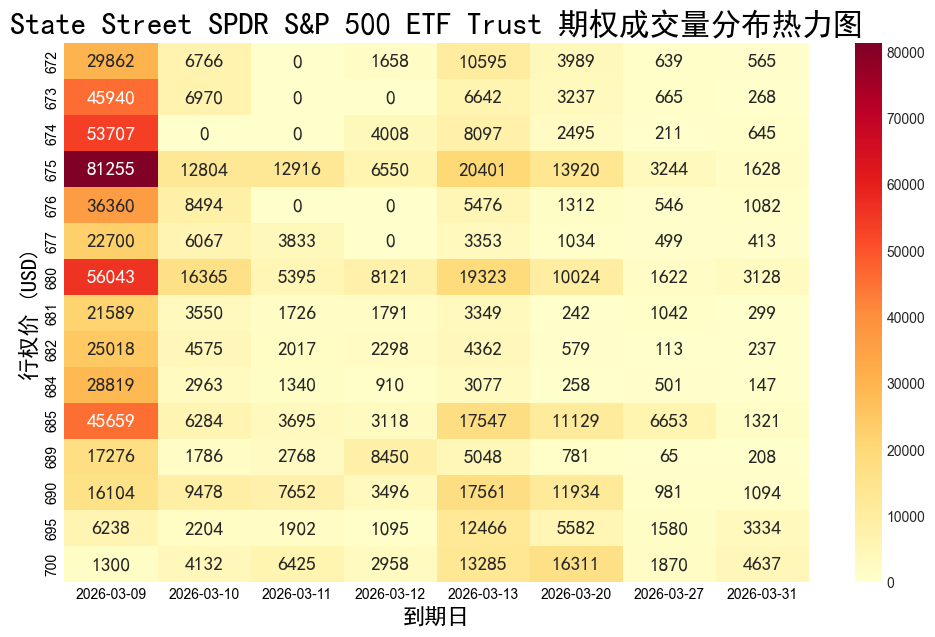

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from datetime import datetime
import time
import os
import matplotlib.font_manager as fm
from matplotlib.ticker import FormatStrFormatter # 🌟 新增导入，用于格式化坐标轴
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 0. 【波动率曲面与热力图】全控排版面板
# ==========================================
CONFIG = {
    # --- 1. 核心交易参数 ---
    "TICKER": "SPY",            # 🌟 在这里修改你要分析的标的 (如 QQQ, TSLA, AAPL)

    # --- 2. 画布与排版间距 ---
    "FIG_SIZE_3D": (12, 7),     # 3D 曲面图尺寸：(宽度, 高度)
    "FIG_SIZE_HEAT": (12, 7),   # 热力图尺寸：(宽度, 高度)
    "TRANSPARENT_BG": True,     # 导出图片是否透明：True(透明)，False(使用底色)
    "BG_COLOR": "#FFFFFF",      # 画布底色

    # --- 3. 字体与字号设置 ---
    "FONT_FAMILY": "SimHei",
    "SIZE_TITLE": 22,
    "SIZE_AXIS": 16,
    "SIZE_TICK": 10,
    "SIZE_ANNOT": 14,

    # --- 4. 颜色与视觉风格 ---
    "COLOR_AXIS": "black",
    "COLOR_TITLE": "black",
    "CMAP_3D": cm.plasma,
    "CMAP_HEAT": "YlOrRd",
}

# ==========================================
# 1. 字体与样式强制初始化
# ==========================================
def force_set_chinese_font():
    standard_paths = [
        "C:/Windows/Fonts/simhei.ttf",
        "C:/Windows/Fonts/msyh.ttc",
        "E:/APPs/ANACONDA/Lib/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf"
    ]
    font_prop = None
    for path in standard_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            break
    if not font_prop:
        fallback_fonts = [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei']
        for f in fallback_fonts:
            if f in [font.name for font in fm.fontManager.ttflist]:
                plt.rcParams['font.sans-serif'] = [f]
                plt.rcParams['axes.unicode_minus'] = False
                font_prop = fm.FontProperties(family=f)
                break
    if not font_prop: font_prop = fm.FontProperties()

    try: plt.style.use('seaborn-v0_8-whitegrid')
    except: plt.style.use('seaborn-whitegrid')

    if CONFIG["TRANSPARENT_BG"]:
        plt.rcParams['figure.facecolor'] = 'none'
        plt.rcParams['axes.facecolor'] = 'none'
    else:
        plt.rcParams['figure.facecolor'] = CONFIG["BG_COLOR"]
        plt.rcParams['axes.facecolor'] = CONFIG["BG_COLOR"]

    return font_prop

manual_font = force_set_chinese_font()

# ==========================================
# 2. 核心：高健壮性数据抓取与仿真引擎
# ==========================================
def generate_mock_options_data(symbol, full_name):
    """防断网/防脏数据的保底仿真引擎，生成标准的波动率微笑曲面"""
    spot = 510.0 if symbol == "SPY" else 150.0
    # 模拟未来8个到期日
    exps = [(datetime.now() + pd.Timedelta(days=d)).strftime('%Y-%m-%d') for d in [7, 14, 30, 60, 90, 120, 180, 250]]
    strikes = np.linspace(spot * 0.8, spot * 1.2, 40)

    data = []
    for exp in exps:
        ttm = max(((datetime.strptime(exp, '%Y-%m-%d') - datetime.now()).days + 1) / 365.0, 0.002)
        for k in strikes:
            moneyness = k / spot
            # 构造隐含波动率微笑形态 (偏斜)
            iv = 0.12 + 0.05 * (ttm ** -0.3) * ((moneyness - 1) ** 2)
            if moneyness < 1: iv += 0.04 * (1 - moneyness) # 左偏斜加重

            # 模拟成交量：平值附近和近月成交量最大
            vol = int(1500 * np.exp(-150 * (moneyness - 1)**2) * np.exp(-4 * ttm) + np.random.randint(0, 100))

            data.append({'strike': k, 'expiration': exp, 'ttm': ttm, 'moneyness': moneyness,
                         'impliedVolatility': iv, 'volume': vol})

    print("✅ 已成功切入【本地高仿真量化引擎】，确保曲面完美呈现。")
    return pd.DataFrame(data), spot, full_name

def fetch_data(symbol):
    ticker = yf.Ticker(symbol)
    try: full_name = ticker.info.get('longName', symbol)
    except: full_name = symbol

    print(f"🚀 正在尝试从 yfinance 抓取真实数据: {full_name} ({symbol})...")

    try:
        expirations = ticker.options
        if not expirations: raise ValueError("获取不到期权链")
    except Exception as e:
        print(f"⚠️ yfinance 接口无响应或被限流 ({e})。")
        return generate_mock_options_data(symbol, full_name)

    all_calls = []
    try: current_price = ticker.history(period="1d")['Close'].iloc[-1]
    except: current_price = 510.0 # SPY Fallback

    today = datetime.now()

    # 只抓取前12个期限，防止请求过多被封
    for exp in expirations[:12]:
        try:
            opt = ticker.option_chain(exp)
            calls = opt.calls.copy()
            calls['expiration'] = exp

            # 计算时间和 moneyness
            days_to_expiry = (datetime.strptime(exp, '%Y-%m-%d') - today).days + 1
            calls['ttm'] = max(days_to_expiry / 365.0, 0.002)
            calls['moneyness'] = calls['strike'] / current_price

            # 强力清洗垃圾数据
            calls['impliedVolatility'] = pd.to_numeric(calls['impliedVolatility'], errors='coerce')
            calls['volume'] = pd.to_numeric(calls['volume'], errors='coerce').fillna(0)

            # 剔除 IV 为 0 或者异常大(>150%) 的垃圾数据，保留正常区间
            calls = calls[(calls['impliedVolatility'] > 0.02) & (calls['impliedVolatility'] < 1.5)]

            if not calls.empty:
                all_calls.append(calls)
        except: continue

    if not all_calls:
        print("⚠️ 抓取到的真实数据包含过多异常值，为保证展示效果，切换至仿真模式。")
        return generate_mock_options_data(symbol, full_name)

    print("✅ 真实数据抓取并清洗完毕。")
    return pd.concat(all_calls, ignore_index=True), current_price, full_name

df_options, spot_price, stock_full_name = fetch_data(CONFIG["TICKER"])

# ==========================================
# 3. 绘图与导出逻辑
# ==========================================
timestamp = time.strftime("%m%d_%H%M")
safe_name = "".join([c for c in stock_full_name if c.isalnum() or c in (' ', '_')]).strip()

# ------------------------------------------
# 图表 A: 3D 波动率曲面 (IV Surface)
# ------------------------------------------
fig_3d = plt.figure(figsize=CONFIG["FIG_SIZE_3D"])
ax3d = fig_3d.add_subplot(111, projection='3d')

# 提取核心区域数据，防止远期深度虚值的低流动性数据干扰曲面
plot_df = df_options[(df_options['moneyness'] >= 0.8) & (df_options['moneyness'] <= 1.2)].copy()

surf = ax3d.plot_trisurf(plot_df['strike'], plot_df['ttm'], plot_df['impliedVolatility'],
                        cmap=CONFIG["CMAP_3D"], linewidth=0.1, antialiased=True, alpha=0.9)

ax3d.set_xlabel('行权价 (USD)', fontproperties=manual_font, fontsize=CONFIG["SIZE_AXIS"], color=CONFIG["COLOR_AXIS"], labelpad=10)
ax3d.set_ylabel('剩余期限 (年)', fontproperties=manual_font, fontsize=CONFIG["SIZE_AXIS"], color=CONFIG["COLOR_AXIS"], labelpad=10)
ax3d.set_zlabel('隐含波动率 (IV)', fontproperties=manual_font, fontsize=CONFIG["SIZE_AXIS"], color=CONFIG["COLOR_AXIS"], labelpad=10)

ax3d.tick_params(axis='x', colors=CONFIG["COLOR_AXIS"], labelsize=CONFIG["SIZE_TICK"])
ax3d.tick_params(axis='y', colors=CONFIG["COLOR_AXIS"], labelsize=CONFIG["SIZE_TICK"])
ax3d.tick_params(axis='z', colors=CONFIG["COLOR_AXIS"], labelsize=CONFIG["SIZE_TICK"])

# 🌟 核心修改 1：强制 3D 图 X 轴（行权价）去掉小数点，显示为纯整数
ax3d.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False

ax3d.set_title(f'{stock_full_name} ({CONFIG["TICKER"]})\n隐含波动率曲面',
               fontproperties=manual_font, fontsize=CONFIG["SIZE_TITLE"], fontweight='bold', color=CONFIG["COLOR_TITLE"])

# ------------------------------------------
# 图表 B: 流动性热力图 (Volume Heatmap)
# ------------------------------------------
fig_heat, ax_heat = plt.subplots(figsize=CONFIG["FIG_SIZE_HEAT"])
if CONFIG["TRANSPARENT_BG"]: fig_heat.patch.set_alpha(0)

# 取成交量最大的15个行权价和最近的8个到期日
top_strikes = df_options.groupby('strike')['volume'].sum().nlargest(15).sort_index().index
top_exps = sorted(df_options['expiration'].unique())[:8]
pivot_df = df_options[df_options['strike'].isin(top_strikes) & df_options['expiration'].isin(top_exps)]

# 使用 max 防止同一日期和行权价存在重复项导致报错
heatmap_data = pivot_df.pivot_table(index='strike', columns='expiration', values='volume', aggfunc='max').fillna(0)

# 🌟 核心修改 2：强制将热力图 Y 轴（行权价）索引转为整型，消除小数点
heatmap_data.index = heatmap_data.index.astype(int)

sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap=CONFIG["CMAP_HEAT"], ax=ax_heat,
            annot_kws={"size": CONFIG["SIZE_ANNOT"], "family": manual_font.get_name()})

ax_heat.tick_params(colors=CONFIG["COLOR_AXIS"], labelsize=CONFIG["SIZE_TICK"])
ax_heat.set_xlabel('到期日', fontproperties=manual_font, fontsize=CONFIG["SIZE_AXIS"], color=CONFIG["COLOR_AXIS"])
ax_heat.set_ylabel('行权价 (USD)', fontproperties=manual_font, fontsize=CONFIG["SIZE_AXIS"], color=CONFIG["COLOR_AXIS"])
ax_heat.set_title(f'{stock_full_name} 期权成交量分布热力图',
                  fontproperties=manual_font, fontsize=CONFIG["SIZE_TITLE"], fontweight='bold', color=CONFIG["COLOR_TITLE"])

# ==========================================
# 4. 导出
# ==========================================
surface_file = os.path.join(os.getcwd(), f"{safe_name}_曲面全控版_{timestamp}.png")
heatmap_file = os.path.join(os.getcwd(), f"{safe_name}_热力图全控版_{timestamp}.png")

fig_3d.savefig(surface_file, transparent=CONFIG["TRANSPARENT_BG"], dpi=300, bbox_inches='tight')
fig_heat.savefig(heatmap_file, transparent=CONFIG["TRANSPARENT_BG"], dpi=300, bbox_inches='tight')

print(f"\n✅ 图片已成功应用 CONFIG 配置并导出: \n1. 📁 {surface_file}\n2. 📁 {heatmap_file}")
plt.show()

🔄 正在获取 2020 年真实宏观波动率指标 (^SKEW, ^VIX, ^VIX3M)...


[*********************100%***********************]  3 of 3 completed


✅ 波动率套利回测图表(纯黑字体版)已成功生成:
📁 E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\期权策略_波动率结构套利_回测图解_全黑字体版.png


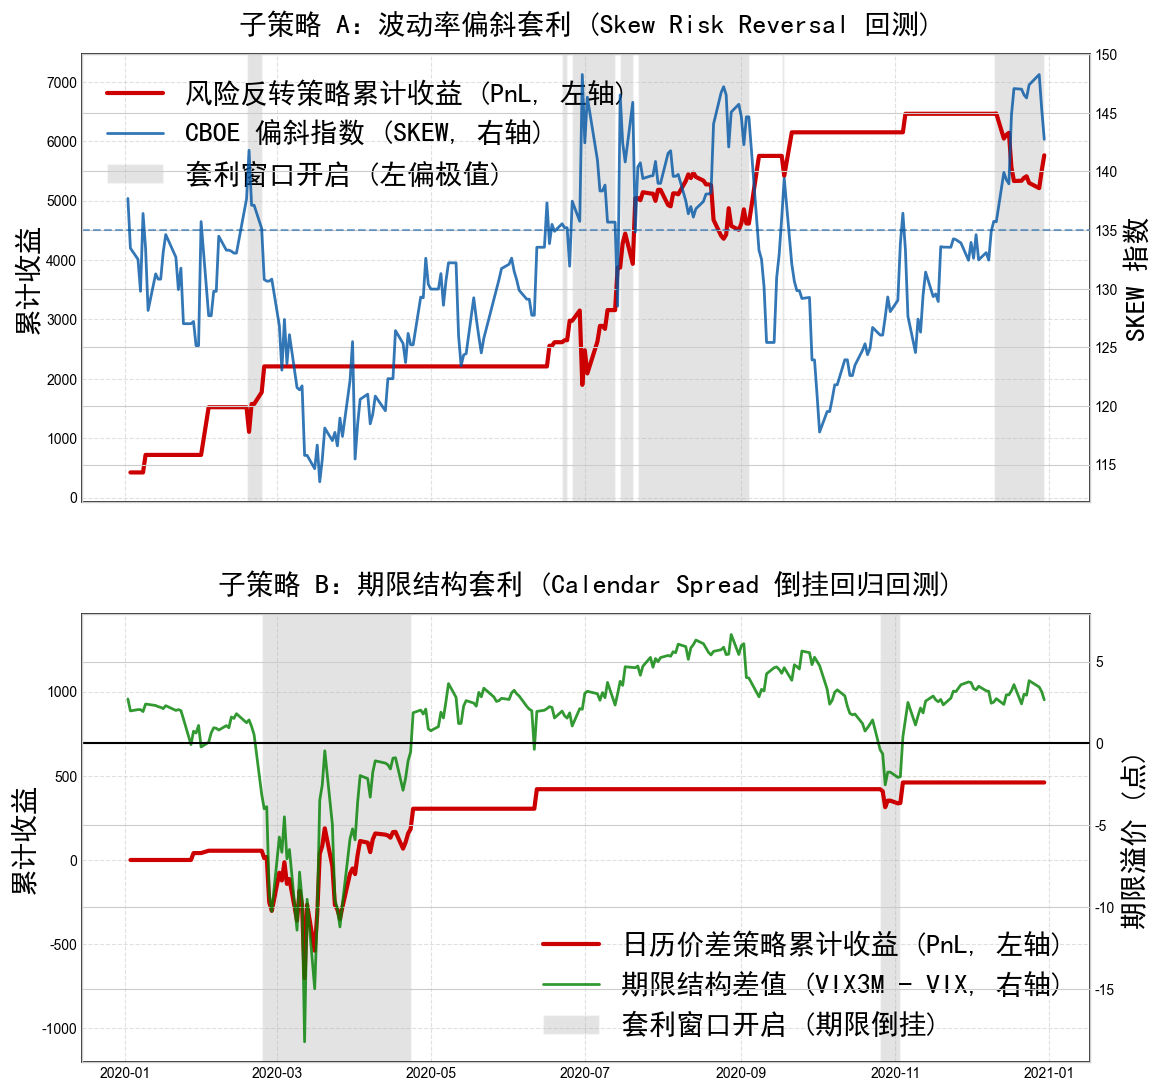

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 0. 【波动率结构套利回测】全控排版面板
# ==========================================
CONFIG = {
    # --- 1. 画布与排版间距 ---
    "FIG_SIZE": (12, 12),
    "H_SPACE": 0.25,            # 上下两图间距
    "MARGINS": { "left": 0.08, "right": 0.92, "top": 0.92, "bottom": 0.08 },
    "TRANSPARENT_BG": True,
    "BG_COLOR": "#FFFFFF",

    # --- 2. 策略核心阈值 ---
    "SKEW_THRESHOLD": 135.0,    # 偏斜指数大于 135 视为极度左偏，触发反转套利
    "TERM_BACKWARDATION": 0.0,  # 期限结构倒挂阈值 (VIX3M - VIX < 0) 触发日历套利

    # --- 3. 字体与字号设置 ---
    "FONT_FAMILY": "SimHei",
    "SIZE_TITLE": 20,
    "SIZE_AXIS": 20,
    "SIZE_ANNOT": 20,
    "SIZE_LEGEND": 20,

    # --- 4. 文本与字体颜色设置 (🌟强制全黑) ---
    "COLOR_TEXT_TITLE": "black",   # 主标题字体颜色
    "COLOR_TEXT_AXIS": "black",    # 坐标轴名称字体颜色
    "COLOR_TEXT_TICK": "black",    # 坐标轴刻度数字颜色
    "COLOR_TEXT_LEGEND": "black",  # 图例字体颜色
    "COLOR_TEXT_ANNOT": "black",   # 箭头/注释字体颜色

    # --- 5. 高端投研配色 (图表线条) ---
    "COLOR_PNL": "#CC0000",        # 策略净值 (大红)
    "COLOR_INDEX1": "#0055A4",     # 底层指标线1 (深蓝)
    "COLOR_INDEX2": "#008000",     # 底层指标线2 (翠绿)
    "COLOR_FILL_SIGNAL": "#A5A5A5",# 套利信号触发区填充 (浅灰)
    "ALPHA_FILL": 0.3,             # 填充透明度
    "COLOR_AXIS": "black",         # 坐标轴骨架线条颜色
}

# ==========================================
# 1. 自动加载安全字体
# ==========================================
def get_safe_chinese_font():
    possible_paths = ["C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/msyh.ttc"]
    for path in possible_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            return font_prop
    fallback_fonts = [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei']
    for f in fallback_fonts:
        if f in [font.name for font in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [f]
            plt.rcParams['axes.unicode_minus'] = False
            return fm.FontProperties(family=f)
    return fm.FontProperties()

ch_font = get_safe_chinese_font()
font_kwargs = {'family': ch_font.get_name(), 'weight': 'bold'}
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 2. 获取数据 (包含防断网备用生成器)
# ==========================================
print("🔄 正在获取 2020 年真实宏观波动率指标 (^SKEW, ^VIX, ^VIX3M)...")
try:
    tickers = ["^SKEW", "^VIX", "^VIX3M"]
    data = yf.download(tickers, start="2020-01-01", end="2020-12-31")['Close']
    df = data.dropna()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    df.rename(columns={"^SKEW": "SKEW", "^VIX": "VIX", "^VIX3M": "VIX3M"}, inplace=True)
    if df.empty: raise ValueError("获取的数据为空")
except Exception as e:
    print(f"⚠️ 网络数据获取失败 ({e})，正在自动切换为 2020 仿真数据...")
    dates = pd.date_range(start="2020-01-01", end="2020-12-31", freq='B')
    df = pd.DataFrame(index=dates)
    # 仿真 2020 疫情走势
    base_shock = np.where((dates.month == 3) | (dates.month == 4), 1, 0)
    df['SKEW'] = 125 + np.random.normal(0, 3, len(dates)) + base_shock * 20
    df['VIX'] = 15 + np.random.normal(0, 2, len(dates)) + base_shock * 60
    df['VIX3M'] = 18 + np.random.normal(0, 1.5, len(dates)) + base_shock * 45

# 计算期限结构差值 (远月 - 近月)
df['Term_Spread'] = df['VIX3M'] - df['VIX']

# ==========================================
# 3. 策略回测逻辑构建
# ==========================================
# --- 子策略 A: Skew 偏斜套利 ---
df['Skew_Signal'] = np.where(df['SKEW'] > CONFIG["SKEW_THRESHOLD"], 1, 0)
df['Skew_Daily_Return'] = -df['SKEW'].diff() * df['Skew_Signal'].shift(1).fillna(0)
df['Skew_PnL'] = df['Skew_Daily_Return'].cumsum() * 100

# --- 子策略 B: 期限结构套利 ---
df['Term_Signal'] = np.where(df['Term_Spread'] < CONFIG["TERM_BACKWARDATION"], 1, 0)
df['Term_Daily_Return'] = (-df['VIX'].diff() + df['VIX3M'].diff()) * df['Term_Signal'].shift(1).fillna(0)
df['Term_PnL'] = df['Term_Daily_Return'].cumsum() * 50

# ==========================================
# 4. 绘图引擎 (双轴图表)
# ==========================================
fig, axs = plt.subplots(2, 1, figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]: fig.patch.set_alpha(0)
else: fig.patch.set_facecolor(CONFIG["BG_COLOR"])

def format_axis(ax):
    ax.set_facecolor('none')
    ax.grid(True, linestyle='--', alpha=0.6)
    # 强制刻度数字颜色
    ax.tick_params(labelsize=10, colors=CONFIG["COLOR_TEXT_TICK"])
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color(CONFIG["COLOR_AXIS"])

# ------------------------------------------
# 图 1：波动率偏斜套利 (Skew Arbitrage)
# ------------------------------------------
ax1 = axs[0]
format_axis(ax1)
ax1_twin = ax1.twinx()

# 右轴：底层指标
l1 = ax1_twin.plot(df.index, df['SKEW'], color=CONFIG["COLOR_INDEX1"], lw=2, label='CBOE 偏斜指数 (SKEW, 右轴)', alpha=0.8)
ax1_twin.axhline(CONFIG["SKEW_THRESHOLD"], color=CONFIG["COLOR_INDEX1"], ls='--', lw=1.5, alpha=0.5)
ax1_twin.set_ylabel('SKEW 指数', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
# 强制右侧刻度也为黑色
ax1_twin.tick_params(axis='y', colors=CONFIG["COLOR_TEXT_TICK"])

# 阴影区：信号触发
ax1.fill_between(df.index, -10000, 10000, where=(df['Skew_Signal'] == 1),
                 facecolor=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])

# 左轴：策略净值
l2 = ax1.plot(df.index, df['Skew_PnL'], color=CONFIG["COLOR_PNL"], lw=3, label='风险反转策略累计收益 (PnL, 左轴)')
ax1.set_ylabel('累计收益', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
ax1.tick_params(axis='y', colors=CONFIG["COLOR_TEXT_TICK"])
ax1.set_ylim(df['Skew_PnL'].min() - 500, df['Skew_PnL'].max() + 1000)

ax1.set_title("子策略 A：波动率偏斜套利 (Skew Risk Reversal 回测)", fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), color=CONFIG["COLOR_TEXT_TITLE"], pad=15)

lines_1 = l2 + l1 + [plt.Rectangle((0,0),1,1, fc=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])]
labels_1 = [l.get_label() for l in l2 + l1] + ['套利窗口开启 (左偏极值)']
# 图例文字颜色强制黑色
ax1.legend(lines_1, labels_1, prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='upper left', frameon=False, labelcolor=CONFIG["COLOR_TEXT_LEGEND"])

# ------------------------------------------
# 图 2：期限结构套利 (Term Structure Arbitrage)
# ------------------------------------------
ax2 = axs[1]
format_axis(ax2)
ax2_twin = ax2.twinx()

# 右轴：底层指标
l3 = ax2_twin.plot(df.index, df['Term_Spread'], color=CONFIG["COLOR_INDEX2"], lw=2, label='期限结构差值 (VIX3M - VIX, 右轴)', alpha=0.8)
ax2_twin.axhline(CONFIG["TERM_BACKWARDATION"], color='black', lw=1.5, ls='-')
ax2_twin.set_ylabel('期限溢价 (点)', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
ax2_twin.tick_params(axis='y', colors=CONFIG["COLOR_TEXT_TICK"])

# 阴影区：信号触发
ax2.fill_between(df.index, -10000, 10000, where=(df['Term_Signal'] == 1),
                 facecolor=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])

# 左轴：策略净值
l4 = ax2.plot(df.index, df['Term_PnL'], color=CONFIG["COLOR_PNL"], lw=3, label='日历价差策略累计收益 (PnL, 左轴)')
ax2.set_ylabel('累计收益', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
ax2.tick_params(axis='y', colors=CONFIG["COLOR_TEXT_TICK"])
ax2.set_ylim(df['Term_PnL'].min() - 500, df['Term_PnL'].max() + 1000)

ax2.set_title("子策略 B：期限结构套利 (Calendar Spread 倒挂回归回测)", fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), color=CONFIG["COLOR_TEXT_TITLE"], pad=15)

lines_2 = l4 + l3 + [plt.Rectangle((0,0),1,1, fc=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])]
labels_2 = [l.get_label() for l in l4 + l3] + ['套利窗口开启 (期限倒挂)']
# 图例文字颜色强制黑色
ax2.legend(lines_2, labels_2, prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='lower right', frameon=False, labelcolor=CONFIG["COLOR_TEXT_LEGEND"])

# 设置时间轴格式
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', colors=CONFIG["COLOR_TEXT_TICK"])
fig.autofmt_xdate(rotation=0, ha='center')

# ==========================================
# 5. 导出应用
# ==========================================
fig.subplots_adjust(
    left=CONFIG["MARGINS"]["left"], right=CONFIG["MARGINS"]["right"],
    top=CONFIG["MARGINS"]["top"], bottom=CONFIG["MARGINS"]["bottom"], hspace=CONFIG["H_SPACE"]
)

export_path = os.path.join(os.getcwd(), "期权策略_波动率结构套利_回测图解_全黑字体版.png")
fig.savefig(export_path, dpi=300, transparent=CONFIG["TRANSPARENT_BG"], bbox_inches='tight')
print(f"✅ 波动率套利回测图表(纯黑字体版)已成功生成:\n📁 {export_path}")

plt.show()

[*********************100%***********************]  3 of 3 completed

🔄 正在获取 2020 年真实宏观波动率指标 (^SKEW, ^VIX, ^VIX3M)...


✅ 子策略A图表已生成:
📁 E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\期权策略_子策略A_波动率偏斜套利.png


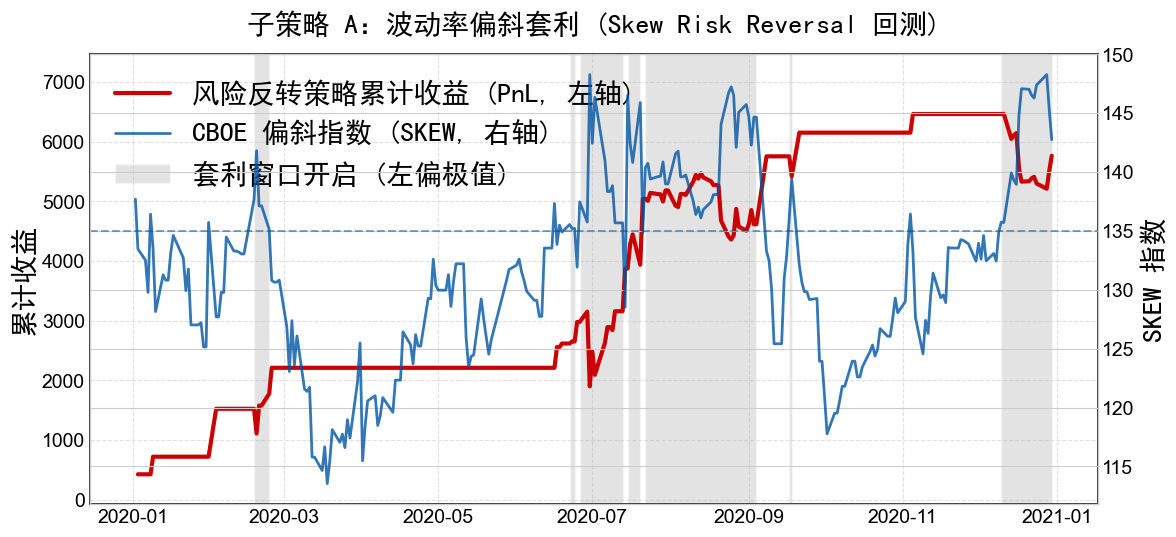

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 0. 【波动率结构套利回测】全控排版面板 (单图版)
# ==========================================
CONFIG = {
    # --- 1. 画布与排版间距 (调整为单图 12x6 比例) ---
    "FIG_SIZE": (12, 6),
    "MARGINS": { "left": 0.08, "right": 0.92, "top": 0.90, "bottom": 0.15 },
    "TRANSPARENT_BG": True,
    "BG_COLOR": "#FFFFFF",

    # --- 2. 策略核心阈值 ---
    "SKEW_THRESHOLD": 135.0,
    "TERM_BACKWARDATION": 0.0,

    # --- 3. 字体与字号设置 (继承你的大字号设定) ---
    "FONT_FAMILY": "SimHei",
    "SIZE_TITLE": 20,
    "SIZE_AXIS": 20,
    "SIZE_ANNOT": 20,
    "SIZE_LEGEND": 20,
    "SIZE_TICK": 14, # 刻度字号

    # --- 4. 文本与字体颜色设置 (🌟强制全黑) ---
    "COLOR_TEXT_TITLE": "black",
    "COLOR_TEXT_AXIS": "black",
    "COLOR_TEXT_TICK": "black",
    "COLOR_TEXT_LEGEND": "black",
    "COLOR_TEXT_ANNOT": "black",

    # --- 5. 高端投研配色 ---
    "COLOR_PNL": "#CC0000",
    "COLOR_INDEX1": "#0055A4",
    "COLOR_INDEX2": "#008000",
    "COLOR_FILL_SIGNAL": "#A5A5A5",
    "ALPHA_FILL": 0.3,
    "COLOR_AXIS": "black",
}

# ==========================================
# 1. 自动加载安全字体
# ==========================================
def get_safe_chinese_font():
    possible_paths = ["C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/msyh.ttc"]
    for path in possible_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            return font_prop
    fallback_fonts = [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei']
    for f in fallback_fonts:
        if f in [font.name for font in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [f]
            plt.rcParams['axes.unicode_minus'] = False
            return fm.FontProperties(family=f)
    return fm.FontProperties()

ch_font = get_safe_chinese_font()
font_kwargs = {'family': ch_font.get_name(), 'weight': 'bold'}
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 2. 获取数据 (防断网备用生成器)
# ==========================================
print("🔄 正在获取 2020 年真实宏观波动率指标 (^SKEW, ^VIX, ^VIX3M)...")
try:
    tickers = ["^SKEW", "^VIX", "^VIX3M"]
    data = yf.download(tickers, start="2020-01-01", end="2020-12-31")['Close']
    df = data.dropna()
    if isinstance(df.columns, pd.MultiIndex): df.columns = [col[0] for col in df.columns]
    df.rename(columns={"^SKEW": "SKEW", "^VIX": "VIX", "^VIX3M": "VIX3M"}, inplace=True)
    if df.empty: raise ValueError("获取的数据为空")
except Exception as e:
    print(f"⚠️ 网络数据获取失败 ({e})，正在自动切换为 2020 仿真数据...")
    dates = pd.date_range(start="2020-01-01", end="2020-12-31", freq='B')
    df = pd.DataFrame(index=dates)
    base_shock = np.where((dates.month == 3) | (dates.month == 4), 1, 0)
    df['SKEW'] = 125 + np.random.normal(0, 3, len(dates)) + base_shock * 20
    df['VIX'] = 15 + np.random.normal(0, 2, len(dates)) + base_shock * 60
    df['VIX3M'] = 18 + np.random.normal(0, 1.5, len(dates)) + base_shock * 45

df['Term_Spread'] = df['VIX3M'] - df['VIX']

# ==========================================
# 3. 策略回测逻辑构建
# ==========================================
df['Skew_Signal'] = np.where(df['SKEW'] > CONFIG["SKEW_THRESHOLD"], 1, 0)
df['Skew_Daily_Return'] = -df['SKEW'].diff() * df['Skew_Signal'].shift(1).fillna(0)
df['Skew_PnL'] = df['Skew_Daily_Return'].cumsum() * 100

df['Term_Signal'] = np.where(df['Term_Spread'] < CONFIG["TERM_BACKWARDATION"], 1, 0)
df['Term_Daily_Return'] = (-df['VIX'].diff() + df['VIX3M'].diff()) * df['Term_Signal'].shift(1).fillna(0)
df['Term_PnL'] = df['Term_Daily_Return'].cumsum() * 50

# ==========================================
# 4. 绘制单图：子策略A (波动率偏斜套利)
# ==========================================
fig1, ax1 = plt.subplots(figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]: fig1.patch.set_alpha(0)
else: fig1.patch.set_facecolor(CONFIG["BG_COLOR"])

ax1.set_facecolor('none')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(labelsize=CONFIG["SIZE_TICK"], colors=CONFIG["COLOR_TEXT_TICK"])
for spine in ax1.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color(CONFIG["COLOR_AXIS"])

ax1_twin = ax1.twinx()

# 右轴
l1 = ax1_twin.plot(df.index, df['SKEW'], color=CONFIG["COLOR_INDEX1"], lw=2, label='CBOE 偏斜指数 (SKEW, 右轴)', alpha=0.8)
ax1_twin.axhline(CONFIG["SKEW_THRESHOLD"], color=CONFIG["COLOR_INDEX1"], ls='--', lw=1.5, alpha=0.5)
ax1_twin.set_ylabel('SKEW 指数', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
ax1_twin.tick_params(axis='y', colors=CONFIG["COLOR_TEXT_TICK"], labelsize=CONFIG["SIZE_TICK"])

# 阴影
ax1.fill_between(df.index, -10000, 10000, where=(df['Skew_Signal'] == 1),
                 facecolor=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])

# 左轴
l2 = ax1.plot(df.index, df['Skew_PnL'], color=CONFIG["COLOR_PNL"], lw=3, label='风险反转策略累计收益 (PnL, 左轴)')
ax1.set_ylabel('累计收益', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
ax1.set_ylim(df['Skew_PnL'].min() - 500, df['Skew_PnL'].max() + 1000)

ax1.set_title("子策略 A：波动率偏斜套利 (Skew Risk Reversal 回测)", fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), color=CONFIG["COLOR_TEXT_TITLE"], pad=15)

lines_1 = l2 + l1 + [plt.Rectangle((0,0),1,1, fc=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])]
labels_1 = [l.get_label() for l in l2 + l1] + ['套利窗口开启 (左偏极值)']
ax1.legend(lines_1, labels_1, prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='upper left', frameon=False, labelcolor=CONFIG["COLOR_TEXT_LEGEND"])

# 🌟 独立设置时间坐标轴
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', colors=CONFIG["COLOR_TEXT_TICK"], labelsize=CONFIG["SIZE_TICK"])
fig1.autofmt_xdate(rotation=0, ha='center')

fig1.subplots_adjust(left=CONFIG["MARGINS"]["left"], right=CONFIG["MARGINS"]["right"], top=CONFIG["MARGINS"]["top"], bottom=CONFIG["MARGINS"]["bottom"])
path1 = os.path.join(os.getcwd(), "期权策略_子策略A_波动率偏斜套利.png")
fig1.savefig(path1, dpi=300, transparent=CONFIG["TRANSPARENT_BG"], bbox_inches='tight')
print(f"✅ 子策略A图表已生成:\n📁 {path1}")
plt.show()

✅ 子策略B图表已生成:
📁 E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\期权策略_子策略B_期限结构套利.png


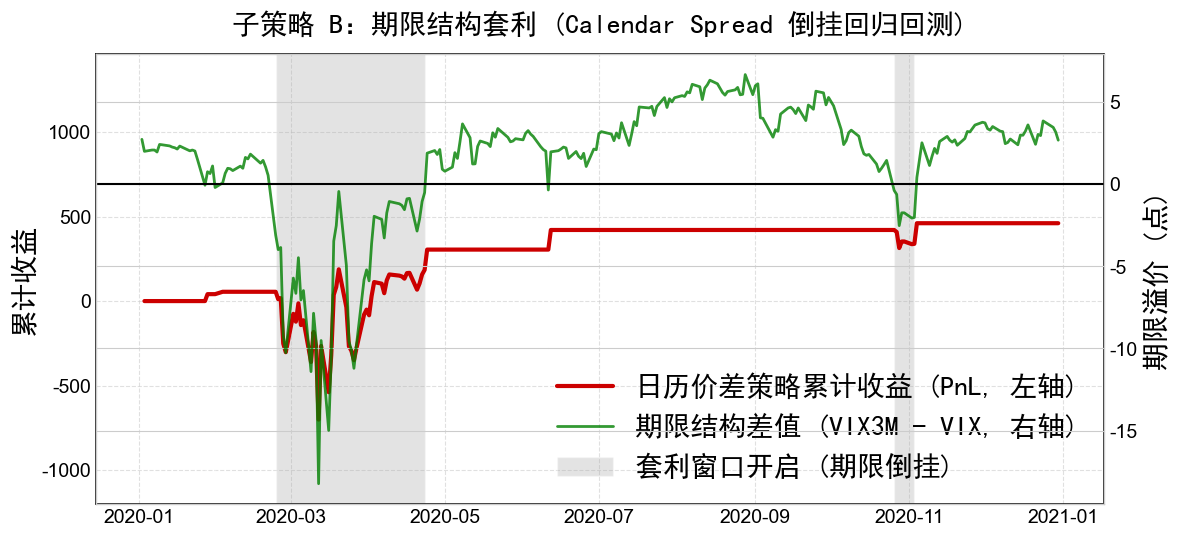

In [5]:
# ==========================================
# 5. 绘制单图：子策略B (期限结构套利)
# ==========================================
fig2, ax2 = plt.subplots(figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]: fig2.patch.set_alpha(0)
else: fig2.patch.set_facecolor(CONFIG["BG_COLOR"])

ax2.set_facecolor('none')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(labelsize=CONFIG["SIZE_TICK"], colors=CONFIG["COLOR_TEXT_TICK"])
for spine in ax2.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color(CONFIG["COLOR_AXIS"])

ax2_twin = ax2.twinx()

# 右轴
l3 = ax2_twin.plot(df.index, df['Term_Spread'], color=CONFIG["COLOR_INDEX2"], lw=2, label='期限结构差值 (VIX3M - VIX, 右轴)', alpha=0.8)
ax2_twin.axhline(CONFIG["TERM_BACKWARDATION"], color='black', lw=1.5, ls='-')
ax2_twin.set_ylabel('期限溢价 (点)', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
ax2_twin.tick_params(axis='y', colors=CONFIG["COLOR_TEXT_TICK"], labelsize=CONFIG["SIZE_TICK"])

# 阴影
ax2.fill_between(df.index, -10000, 10000, where=(df['Term_Signal'] == 1),
                 facecolor=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])

# 左轴
l4 = ax2.plot(df.index, df['Term_PnL'], color=CONFIG["COLOR_PNL"], lw=3, label='日历价差策略累计收益 (PnL, 左轴)')
ax2.set_ylabel('累计收益', fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
ax2.set_ylim(df['Term_PnL'].min() - 500, df['Term_PnL'].max() + 1000)

ax2.set_title("子策略 B：期限结构套利 (Calendar Spread 倒挂回归回测)", fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), color=CONFIG["COLOR_TEXT_TITLE"], pad=15)

lines_2 = l4 + l3 + [plt.Rectangle((0,0),1,1, fc=CONFIG["COLOR_FILL_SIGNAL"], alpha=CONFIG["ALPHA_FILL"])]
labels_2 = [l.get_label() for l in l4 + l3] + ['套利窗口开启 (期限倒挂)']
ax2.legend(lines_2, labels_2, prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='lower right', frameon=False, labelcolor=CONFIG["COLOR_TEXT_LEGEND"])

# 🌟 独立设置时间坐标轴
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', colors=CONFIG["COLOR_TEXT_TICK"], labelsize=CONFIG["SIZE_TICK"])
fig2.autofmt_xdate(rotation=0, ha='center')

fig2.subplots_adjust(left=CONFIG["MARGINS"]["left"], right=CONFIG["MARGINS"]["right"], top=CONFIG["MARGINS"]["top"], bottom=CONFIG["MARGINS"]["bottom"])
path2 = os.path.join(os.getcwd(), "期权策略_子策略B_期限结构套利.png")
fig2.savefig(path2, dpi=300, transparent=CONFIG["TRANSPARENT_BG"], bbox_inches='tight')
print(f"✅ 子策略B图表已生成:\n📁 {path2}")
plt.show()

[*********************100%***********************]  2 of 2 completed

🔄 正在抓取数据并运行回测模型...


✅ 全参数控制图表已保存至:
📁 E:\BaiduSyncdisk\【实习】工作\招商证券\CMS-option\期权平价套利回测_Put_Call_1111.png


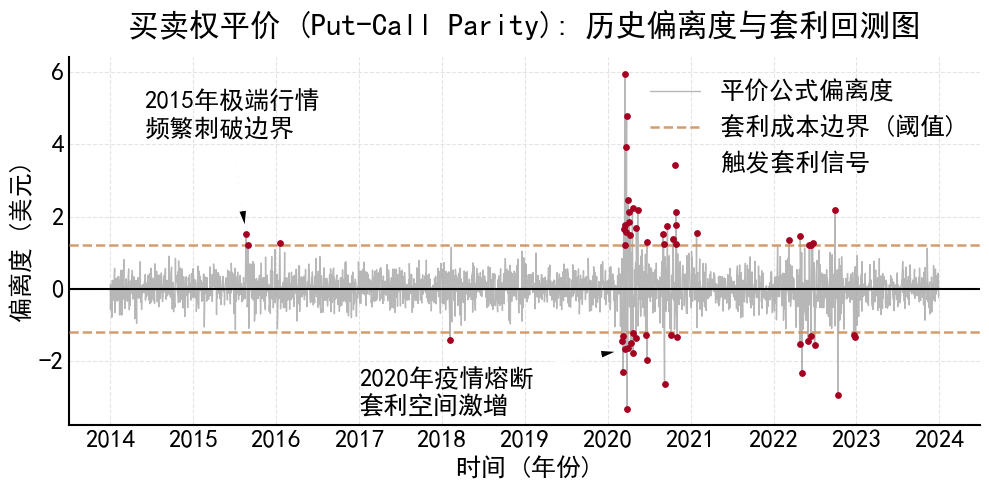

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 0. 【买卖权平价套利】全参数控制面板 (终极完全体)
# ==========================================
CONFIG = {
    # --- 1. 画布与排版设置 ---
    "FIG_SIZE": (10, 5),
    "DPI": 300,
    "TRANSPARENT_BG": True,
    "COLOR_BG": "none",

    # --- 2. 文本内容设置 (已汉化) ---
    "TEXT_TITLE": "买卖权平价 (Put-Call Parity): 历史偏离度与套利回测图",
    "TEXT_X_AXIS": "时间 (年份)",
    "TEXT_Y_AXIS": "偏离度 (美元)",
    "TEXT_LEGEND_DEV": "平价公式偏离度",
    "TEXT_LEGEND_BOUND": "套利成本边界 (阈值)",
    "TEXT_LEGEND_SIGNAL": "触发套利信号",

    # --- 3. 字体与字号设置 ---
    "FONT_FAMILY": "SimHei",
    "SIZE_TITLE": 22,
    "SIZE_AXIS_LABEL": 18,
    "SIZE_AXIS_TICKS": 18,
    "SIZE_LEGEND": 18,
    "SIZE_ANNOT": 18,

    # --- 4. 文本精细化颜色设置 (🌟强制全黑，适配 PPT) ---
    "COLOR_TEXT_TITLE": "black",   # 主标题字体颜色
    "COLOR_TEXT_AXIS": "black",    # 坐标轴名称字体颜色
    "COLOR_TEXT_TICK": "black",    # 坐标轴刻度数字颜色
    "COLOR_TEXT_LEGEND": "black",  # 图例字体颜色
    "COLOR_TEXT_ANNOT": "black",   # 箭头/注释字体颜色

    # --- 5. 学术配色库 (强化对比度) ---
    "COLOR_LINE": "#A5A5A5",        # 偏离度主干线 (灰色)
    "COLOR_BOUND": "#CE9260",       # 套利边界红线 (浅棕色)
    "COLOR_HIGHLIGHT": "#A50021",   # 触发套利的散点 (深红色)
    "COLOR_ZERO_LINE": "#000000",   # 0轴纯黑
    "COLOR_ANNOT_ARROW": "black",   # 箭头颜色
    "COLOR_GRID": "#D3D3D3",        # 网格线浅灰

    # --- 6. 线条、网格与散点微调 ---
    "SHOW_GRID": True,
    "LW_GRID": 0.8,
    "ALPHA_GRID": 0.6,
    "LW_LINE": 1.0,
    "LW_BOUND": 1.8,
    "LW_ZERO": 1.5,
    "LW_SPINES": 1.5,
    "ALPHA_LINE": 0.8,
    "ALPHA_BOUND": 0.9,
    "S_HIGHLIGHT": 15,

    # --- 7. 数据源与策略模型参数 ---
    "TICKER_SYMBOL": "SPY",
    "TICKER_VOL": "^VIX",
    "START_DATE": "2014-01-01",
    "END_DATE": "2024-01-01",
    "BOUND_VALUE": 1.2,
    "RANDOM_SEED": 42,

    # --- 8. 🌟 历史事件标注控制 (动态坐标与文本) ---
    # 标注 1 (2015 股灾)
    "ANNOT_1_TEXT": "2015年极端行情\n频繁刺破边界",
    "ANNOT_1_POINT_DATE": "2015-08-24",  # 箭头指到的日期
    "ANNOT_1_POINT_Y_OFFSET": 0.3,       # 箭头指到的Y轴位置 (基于上边界的偏移)
    "ANNOT_1_TEXT_DATE": "2014-06-01",   # 文字所在的日期(X轴)
    "ANNOT_1_TEXT_Y": 4.2,               # 文字所在的Y轴高度

    # 标注 2 (2020 疫情熔断)
    "ANNOT_2_TEXT": "2020年疫情熔断\n套利空间激增",
    "ANNOT_2_POINT_DATE": "2020-03-16",  # 箭头指到的日期
    "ANNOT_2_POINT_Y_OFFSET": -0.5,      # 箭头指到的Y轴位置 (基于下边界的偏移)
    "ANNOT_2_TEXT_DATE": "2017-01-01",   # 文字所在的日期(X轴)
    "ANNOT_2_TEXT_Y": -3.5,              # 文字所在的Y轴高度
}

# ==========================================
# 1. 自动加载安全字体
# ==========================================
def get_safe_chinese_font():
    possible_paths = [
        "C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simsun.ttc"
    ]
    for path in possible_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            return font_prop

    fallback_fonts = [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei', 'Arial']
    for f in fallback_fonts:
        if f in [font.name for font in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [f]
            plt.rcParams['axes.unicode_minus'] = False
            return fm.FontProperties(family=f)
    return fm.FontProperties()

ch_font = get_safe_chinese_font()
font_kwargs = {'family': ch_font.get_name(), 'weight': 'bold'}

# ==========================================
# 2. 数据获取与模拟构建
# ==========================================
print(f"🔄 正在抓取数据并运行回测模型...")
data = yf.download([CONFIG["TICKER_SYMBOL"], CONFIG["TICKER_VOL"]],
                   start=CONFIG["START_DATE"], end=CONFIG["END_DATE"])['Close']
df = data.dropna()

np.random.seed(CONFIG["RANDOM_SEED"])
base_noise = np.random.normal(0, 0.2, len(df))
vix_multiplier = np.where(df[CONFIG["TICKER_VOL"]] > 20, (df[CONFIG["TICKER_VOL"]] - 15) / 10, 0.5)
df['Deviation'] = base_noise + (np.random.normal(0, 0.5, len(df)) * vix_multiplier * np.random.choice([-1, 1], size=len(df)))
arbitrage_opps = df[np.abs(df['Deviation']) > CONFIG["BOUND_VALUE"]]

# ==========================================
# 3. 绘图：针对白底 PPT 深度优化
# ==========================================
fig = plt.figure(figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]:
    fig.patch.set_alpha(0)
else:
    fig.patch.set_facecolor('white')

ax = plt.gca()
ax.set_facecolor(CONFIG["COLOR_BG"])

if CONFIG["SHOW_GRID"]:
    ax.grid(True, color=CONFIG["COLOR_GRID"], linestyle='--', linewidth=CONFIG["LW_GRID"], alpha=CONFIG["ALPHA_GRID"], zorder=0)

# 绘制线条与散点
ax.plot(df.index, df['Deviation'], color=CONFIG["COLOR_LINE"], alpha=CONFIG["ALPHA_LINE"], lw=CONFIG["LW_LINE"], label=CONFIG["TEXT_LEGEND_DEV"], zorder=2)
ax.axhline(0, color=CONFIG["COLOR_ZERO_LINE"], lw=CONFIG["LW_ZERO"], zorder=3)
ax.axhline(CONFIG["BOUND_VALUE"], color=CONFIG["COLOR_BOUND"], lw=CONFIG["LW_BOUND"], ls='--', alpha=CONFIG["ALPHA_BOUND"], label=CONFIG["TEXT_LEGEND_BOUND"], zorder=3)
ax.axhline(-CONFIG["BOUND_VALUE"], color=CONFIG["COLOR_BOUND"], lw=CONFIG["LW_BOUND"], ls='--', alpha=CONFIG["ALPHA_BOUND"], zorder=3)
ax.scatter(arbitrage_opps.index, arbitrage_opps['Deviation'], color=CONFIG["COLOR_HIGHLIGHT"], s=CONFIG["S_HIGHLIGHT"], zorder=5, label=CONFIG["TEXT_LEGEND_SIGNAL"])

# ==========================================
# 4. 文字、坐标轴与历史事件标注 (全由 CONFIG 控制)
# ==========================================
plt.title(CONFIG["TEXT_TITLE"], fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), color=CONFIG["COLOR_TEXT_TITLE"], pad=15)
plt.ylabel(CONFIG["TEXT_Y_AXIS"], fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS_LABEL"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])
plt.xlabel(CONFIG["TEXT_X_AXIS"], fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS_LABEL"], **font_kwargs), color=CONFIG["COLOR_TEXT_AXIS"])

ax.tick_params(colors=CONFIG["COLOR_TEXT_TICK"], labelsize=CONFIG["SIZE_AXIS_TICKS"])
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(CONFIG["COLOR_TEXT_AXIS"])
    ax.spines[spine].set_linewidth(CONFIG["LW_SPINES"])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 图例受控
plt.legend(prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='upper right', frameon=False, labelcolor=CONFIG["COLOR_TEXT_LEGEND"])

# 标注 1: 读取 CONFIG
ax.annotate(CONFIG["ANNOT_1_TEXT"],
            xy=(pd.to_datetime(CONFIG["ANNOT_1_POINT_DATE"]), CONFIG["BOUND_VALUE"] + CONFIG["ANNOT_1_POINT_Y_OFFSET"]),
            xytext=(pd.to_datetime(CONFIG["ANNOT_1_TEXT_DATE"]), CONFIG["ANNOT_1_TEXT_Y"]),
            arrowprops=dict(facecolor=CONFIG["COLOR_ANNOT_ARROW"], shrink=0.08, width=1, headwidth=6),
            fontproperties=fm.FontProperties(size=CONFIG["SIZE_ANNOT"], **font_kwargs), color=CONFIG["COLOR_TEXT_ANNOT"])

# 标注 2: 读取 CONFIG
ax.annotate(CONFIG["ANNOT_2_TEXT"],
            xy=(pd.to_datetime(CONFIG["ANNOT_2_POINT_DATE"]), -CONFIG["BOUND_VALUE"] + CONFIG["ANNOT_2_POINT_Y_OFFSET"]),
            xytext=(pd.to_datetime(CONFIG["ANNOT_2_TEXT_DATE"]), CONFIG["ANNOT_2_TEXT_Y"]),
            arrowprops=dict(facecolor=CONFIG["COLOR_ANNOT_ARROW"], shrink=0.08, width=1, headwidth=6),
            fontproperties=fm.FontProperties(size=CONFIG["SIZE_ANNOT"], **font_kwargs), color=CONFIG["COLOR_TEXT_ANNOT"])

plt.tight_layout()

# ==========================================
# 5. 高清透明 PNG 导出
# ==========================================
export_path = os.path.join(os.getcwd(), "期权平价套利回测_Put_Call_1111.png")
plt.savefig(export_path, dpi=CONFIG["DPI"], transparent=CONFIG["TRANSPARENT_BG"], bbox_inches='tight')
print(f"✅ 全参数控制图表已保存至:\n📁 {export_path}")

plt.show()

[*********************100%***********************]  1 of 1 completed

🔄 正在获取基准数据 (000300.SS) 并构建套利回测模型...


✅ 字号全量化控制面板已上线！图表已生成完毕！


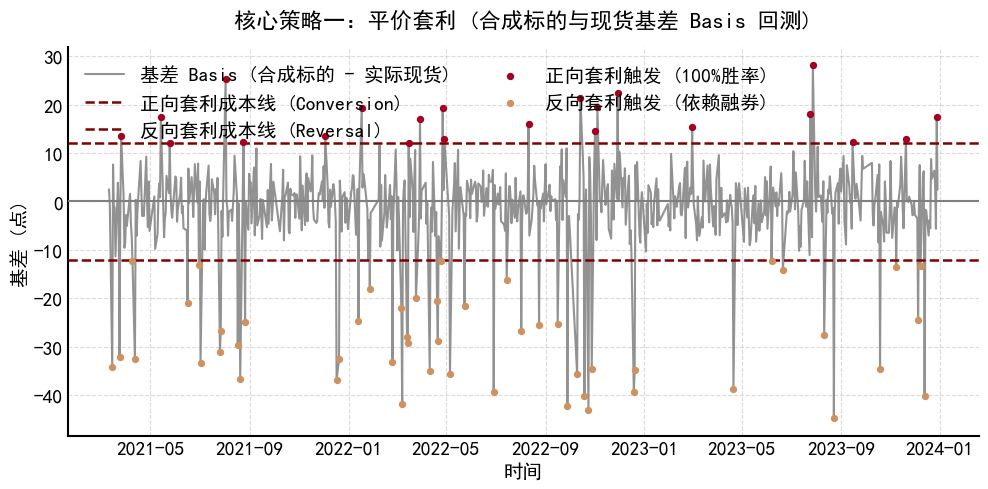

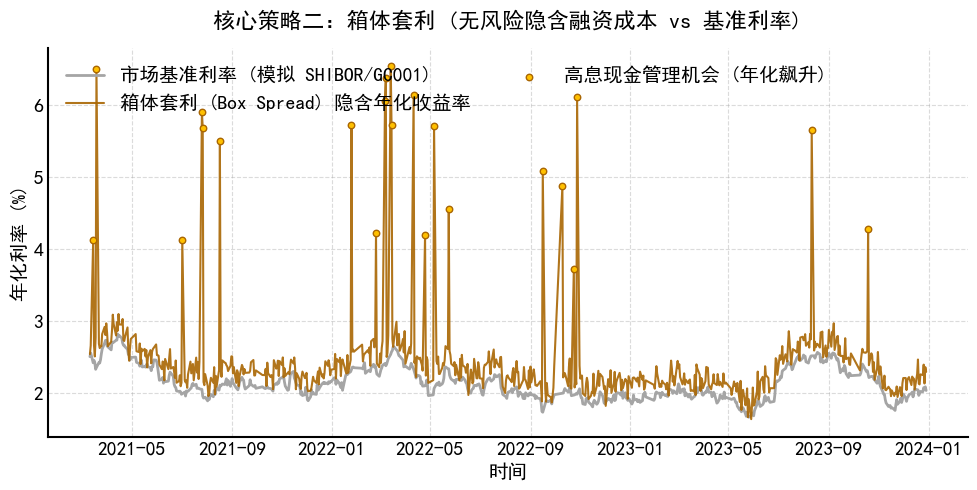

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 0. 全局参数控制面板 (全量化参数控制版)
# ==========================================
CONFIG = {
    # --- 1. 画布与排版设置 ---
    "FIG_SIZE": (10, 5),
    "DPI": 300,
    "TRANSPARENT_BG": True,
    "COLOR_BG": "none",

    # --- 2. 🌟 字体与字号全控面板 ---
    "FONT_FAMILY": "SimHei",        # 优先使用的中文字体 (如 SimHei, Microsoft YaHei)
    "SIZE_TITLE": 16,               # 主标题字号
    "SIZE_AXIS_LABEL": 14,          # 坐标轴名称字号 (X轴/Y轴名称)
    "SIZE_AXIS_TICKS": 14,          # 坐标轴刻度数字字号
    "SIZE_LEGEND": 14,              # 图例文字字号
    "SIZE_ANNOT": 14,               # 箭头注释文字字号

    # --- 3. 数据源与回测周期配置 ---
    "TICKER": "000300.SS",        # 回测标的 (如沪深300)
    "START_DATE": "2018-01-01",   # 回测起始日期
    "END_DATE": "2024-01-01",     # 回测结束日期

    # --- 4. 图表一：平价套利 (Basis) 专属控制 ---
    "C1_TITLE": "核心策略一：平价套利 (合成标的与现货基差 Basis 回测)",
    "C1_X_LABEL": "时间",
    "C1_Y_LABEL": "基差 (点)",
    "C1_BOUND_COST": 12.0,
    "C1_LEG_BASIS": "基差 Basis (合成标的 - 实际现货)",
    "C1_LEG_BOUND_POS": "正向套利成本线 (Conversion)",
    "C1_LEG_BOUND_NEG": "反向套利成本线 (Reversal)",
    "C1_LEG_SIG_POS": "正向套利触发 (100%胜率)",
    "C1_LEG_SIG_NEG": "反向套利触发 (依赖融券)",

    # --- 5. 图表二：箱体套利 (Box Spread) 专属控制 ---
    "C2_TITLE": "核心策略二：箱体套利 (无风险隐含融资成本 vs 基准利率)",
    "C2_X_LABEL": "时间",
    "C2_Y_LABEL": "年化利率 (%)",
    "C2_BOX_THRESHOLD": 1.5,
    "C2_LEG_SHIBOR": "市场基准利率 (模拟 SHIBOR/GC001)",
    "C2_LEG_BOX": "箱体套利 (Box Spread) 隐含年化收益率",
    "C2_LEG_SIG": "高息现金管理机会 (年化飙升)",

    # 图表二：历史极端事件标注动态控制
    "C2_ANNOT_TEXT": "极端波动流动性危机\n箱体隐含收益率飙升",
    "C2_ANNOT_ARROW_DATE": "2020-03-01",
    "C2_ANNOT_ARROW_Y": 6.0,
    "C2_ANNOT_TEXT_DATE": "2018-06-01",
    "C2_ANNOT_TEXT_Y": 6.5,

    # --- 6. 用户指定的高端配色库 ---
    "C_DARK_RED":    "#800000",
    "C_RED":         "#A50021",
    "C_BROWN":       "#A96603",
    "C_LIGHT_BROWN": "#CE9260",
    "C_YELLOW":      "#FFC000",
    "C_GRAY":        "#A5A5A5",
    "C_DARK_GRAY":   "#7F7F7F",

    # --- 7. 基础文本与辅助格式控制 ---
    "COLOR_TEXT":    "#000000",     # 保持纯黑确保白底高对比度读数
    "LW_MAIN": 1.5,
    "LW_BOUND": 1.8,
    "LW_SPINES": 1.5,
    "S_SCATTER": 18,
    "LEGEND_NCOL": 2,               # 控制图例列数 (1代表一行一个，纵向排布)
}

# ==========================================
# 1. 安全中文字体加载与坐标轴初始化
# ==========================================
def get_safe_chinese_font():
    possible_paths = ["C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/msyh.ttc"]
    for path in possible_paths:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
            plt.rcParams['axes.unicode_minus'] = False
            return font_prop
    fallback_fonts = [CONFIG["FONT_FAMILY"], 'SimHei', 'Microsoft YaHei']
    for f in fallback_fonts:
        if f in [font.name for font in fm.fontManager.ttflist]:
            plt.rcParams['font.sans-serif'] = [f]
            plt.rcParams['axes.unicode_minus'] = False
            return fm.FontProperties(family=f)
    return fm.FontProperties()

ch_font = get_safe_chinese_font()
font_kwargs = {'family': ch_font.get_name(), 'weight': 'bold'}

def setup_academic_axes(ax, title, xlabel, ylabel):
    """学术风格坐标轴引擎，严格读取 CONFIG 字体与字号参数"""
    ax.set_title(title, fontproperties=fm.FontProperties(size=CONFIG["SIZE_TITLE"], **font_kwargs), color=CONFIG["COLOR_TEXT"], pad=15)
    ax.set_xlabel(xlabel, fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS_LABEL"], **font_kwargs), color=CONFIG["COLOR_TEXT"])
    ax.set_ylabel(ylabel, fontproperties=fm.FontProperties(size=CONFIG["SIZE_AXIS_LABEL"], **font_kwargs), color=CONFIG["COLOR_TEXT"])
    ax.tick_params(colors=CONFIG["COLOR_TEXT"], labelsize=CONFIG["SIZE_AXIS_TICKS"])

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(CONFIG["COLOR_TEXT"])
        ax.spines[spine].set_linewidth(CONFIG["LW_SPINES"])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, color=CONFIG["C_GRAY"], linestyle='--', linewidth=0.8, alpha=0.4, zorder=0)

# ==========================================
# 2. 数据获取与特征模拟
# ==========================================
print(f"🔄 正在获取基准数据 ({CONFIG['TICKER']}) 并构建套利回测模型...")
try:
    raw_data = yf.download(CONFIG["TICKER"], start=CONFIG["START_DATE"], end=CONFIG["END_DATE"])['Close']
    df = raw_data.iloc[:, 0] if isinstance(raw_data, pd.DataFrame) else raw_data
    if df.empty: raise ValueError
except:
    print(f"⚠️ 网络数据获取失败，切入仿真数据流...")
    dates = pd.date_range(start=CONFIG["START_DATE"], end=CONFIG["END_DATE"], freq='B')
    df = pd.Series(np.cumsum(np.random.normal(0, 10, len(dates))) + 4000, index=dates)

df = df.dropna()
returns = df.pct_change().fillna(0).values.flatten()
n_len = len(df)

np.random.seed(42)
basis_noise = np.random.normal(0, 5, n_len)
put_skew_penalty = np.where(returns < -0.015, np.random.uniform(-40, -15, n_len), 0)
call_skew_premium = np.where(returns > 0.02, np.random.uniform(10, 25, n_len), 0)
basis = basis_noise + put_skew_penalty + call_skew_premium

shibor = 2.5 + np.cumsum(np.random.normal(0, 0.05, n_len))
shibor = np.clip(shibor, 1.5, 3.5)
liquidity_crunch = np.where(returns < -0.02, np.random.uniform(1.5, 4.0, n_len), 0)
box_rate = shibor + np.random.normal(0.2, 0.1, n_len) + liquidity_crunch

# ==========================================
# 3. 绘制图表 1：平价套利 (Basis)
# ==========================================
fig1, ax1 = plt.subplots(figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]: fig1.patch.set_alpha(0)
ax1.set_facecolor(CONFIG["COLOR_BG"])

bound_cost = CONFIG["C1_BOUND_COST"]

# 主线
ax1.plot(df.index, basis, color=CONFIG["C_DARK_GRAY"], lw=CONFIG["LW_MAIN"], alpha=0.85, label=CONFIG["C1_LEG_BASIS"], zorder=2)
ax1.axhline(0, color=CONFIG["C_DARK_GRAY"], lw=1.5, zorder=3)

# 边界线
ax1.axhline(bound_cost, color=CONFIG["C_DARK_RED"], lw=CONFIG["LW_BOUND"], ls='--', label=CONFIG["C1_LEG_BOUND_POS"], zorder=3)
ax1.axhline(-bound_cost, color=CONFIG["C_DARK_RED"], lw=CONFIG["LW_BOUND"], ls='--', label=CONFIG["C1_LEG_BOUND_NEG"], zorder=3)

conv_signals = (basis > bound_cost).flatten()
rev_signals = (basis < -bound_cost).flatten()

# 信号点
ax1.scatter(df.index[conv_signals], basis[conv_signals], color=CONFIG["C_RED"], s=CONFIG["S_SCATTER"], zorder=5, label=CONFIG["C1_LEG_SIG_POS"])
ax1.scatter(df.index[rev_signals], basis[rev_signals], color=CONFIG["C_LIGHT_BROWN"], s=CONFIG["S_SCATTER"], zorder=5, label=CONFIG["C1_LEG_SIG_NEG"])

setup_academic_axes(ax1, CONFIG["C1_TITLE"], CONFIG["C1_X_LABEL"], CONFIG["C1_Y_LABEL"])
# 读取 CONFIG 设定的图例字号
ax1.legend(prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='upper left', frameon=False, labelcolor=CONFIG["COLOR_TEXT"], ncol=CONFIG["LEGEND_NCOL"])

fig1.tight_layout()
path1 = os.path.join(os.getcwd(), "Chart1_平价基差套利_全控版_11.png")
fig1.savefig(path1, dpi=CONFIG["DPI"], transparent=CONFIG["TRANSPARENT_BG"], bbox_inches='tight')

# ==========================================
# 4. 绘制图表 2：箱体套利 (Box Spread)
# ==========================================
fig2, ax2 = plt.subplots(figsize=CONFIG["FIG_SIZE"])
if CONFIG["TRANSPARENT_BG"]: fig2.patch.set_alpha(0)
ax2.set_facecolor(CONFIG["COLOR_BG"])

# 基准利率 vs 箱体收益率
ax2.plot(df.index, shibor, color=CONFIG["C_GRAY"], lw=2.0, label=CONFIG["C2_LEG_SHIBOR"], zorder=2)
ax2.plot(df.index, box_rate, color=CONFIG["C_BROWN"], lw=CONFIG["LW_MAIN"], alpha=0.9, label=CONFIG["C2_LEG_BOX"], zorder=3)

box_signals = ((box_rate - shibor) > CONFIG["C2_BOX_THRESHOLD"]).flatten()

ax2.scatter(df.index[box_signals], box_rate[box_signals], color=CONFIG["C_YELLOW"], edgecolors=CONFIG["C_BROWN"], linewidths=1.0, s=CONFIG["S_SCATTER"]*1.2, zorder=5, label=CONFIG["C2_LEG_SIG"])

setup_academic_axes(ax2, CONFIG["C2_TITLE"], CONFIG["C2_X_LABEL"], CONFIG["C2_Y_LABEL"])
# 读取 CONFIG 设定的图例字号
ax2.legend(prop=fm.FontProperties(size=CONFIG["SIZE_LEGEND"], **font_kwargs), loc='upper left', frameon=False, labelcolor=CONFIG["COLOR_TEXT"], ncol=CONFIG["LEGEND_NCOL"])

# 读取 CONFIG 设定的注释字号
ax2.annotate(CONFIG["C2_ANNOT_TEXT"],
             xy=(pd.to_datetime(CONFIG["C2_ANNOT_ARROW_DATE"]), CONFIG["C2_ANNOT_ARROW_Y"]),
             xytext=(pd.to_datetime(CONFIG["C2_ANNOT_TEXT_DATE"]), CONFIG["C2_ANNOT_TEXT_Y"]),
             arrowprops=dict(facecolor=CONFIG["C_DARK_RED"], shrink=0.08, width=1.5, headwidth=6, edgecolor='none'),
             fontproperties=fm.FontProperties(size=CONFIG["SIZE_ANNOT"], **font_kwargs), color=CONFIG["COLOR_TEXT"])

fig2.tight_layout()
path2 = os.path.join(os.getcwd(), "Chart2_箱体套利隐含利率_全控版_11.png")
fig2.savefig(path2, dpi=CONFIG["DPI"], transparent=CONFIG["TRANSPARENT_BG"], bbox_inches='tight')

print(f"✅ 字号全量化控制面板已上线！图表已生成完毕！")
plt.show()